# 16차시 비지도학습 - 클러스터링과 이상 탐지

## 학습 목표

1. **비지도학습 이해** 지도학습과의 근본적 차이점을 파악하고, 언제 비지도학습을 적용해야 하는지 판단할 수 있음

3. **K-Means 알고리즘 습득** 알고리즘의 수학적 원리와 최적 K 선택 방법을 이해하고 구현할 수 있음

4. **이상 탐지 적용** 클러스터링 기반 이상치 탐지 기법을 실제 제조 데이터에 적용할 수 있음

---

## 실습 데이터셋 소개

### Kaggle Pump Sensor Data

본 강의에서는 실제 산업 현장에서 수집된 **펌프 센서 데이터**를 활용함. 이 데이터셋은 수처리 시설의 펌프 시스템에 설치된 52개 센서에서 1분 간격으로 수집된 시계열 데이터임.

| 항목 | 내용 |
|:---:|:---|
| **출처** | Kaggle (nphantawee/pump-sensor-data) |
| **전체 샘플 수** | 220,320건 (약 153일분) |
| **센서 수** | 52개 (sensor_00 ~ sensor_51) |
| **기록 주기** | 1분 간격 |
| **상태 레이블** | NORMAL, RECOVERING, BROKEN |
| **결측치** | 있음 (전처리 필요) |

### 데이터셋 선정 이유

1. **실제 제조/산업 환경 데이터**: 수처리 시설의 펌프 시스템에서 실제로 수집된 데이터로, 이론적 시뮬레이션이 아닌 현장의 복잡성을 반영함
2. **결측치 존재**: 실제 센서 데이터에서 흔히 발생하는 결측치가 포함되어 전처리의 중요성을 체험할 수 있음
3. **불균형 레이블**: NORMAL이 93.4%를 차지하여 이상 탐지의 현실적 어려움을 체험할 수 있음
4. **다차원 데이터**: 52개 센서 변수로 다차원 클러스터링과 차원 축소의 필요성을 경험할 수 있음

# 1. 비지도학습이란?

## 1.1 지도학습과 비지도학습의 근본적 차이

머신러닝은 학습 데이터에 **정답(레이블)** 이 있는지 여부에 따라 크게 두 가지 패러다임으로 구분됨.

### 핵심 차이점 비교

| 구분 | 지도학습 (Supervised) | 비지도학습 (Unsupervised) |
|:---:|:---|:---|
| **정답 데이터** | 있음 (레이블이 존재) | 없음 (레이블 없이 학습) |
| **학습 목표** | 입력 → 정답 관계 학습 | 데이터 내재 구조/패턴 발견 |
| **대표 문제** | 분류(Classification), 회귀(Regression) | 군집화(Clustering), 차원축소(Dimensionality Reduction) |
| **평가 방법** | 정확도, 오차 등 명확한 지표 | 실루엣 점수 등 상대적 지표 |
| **제조업 예시** | 불량/정상 분류, 수율 예측 | 유사 제품 그룹화, 이상 패턴 탐지 |

### 학습 방식의 개념적 비교

```
[지도학습]
  ┌─────────────┐      ┌─────────────┐      ┌─────────────┐
  │  입력 데이터  │  +   │   정답 레이블  │  →   │   예측 모델   │
  │   (X)       │      │    (y)      │      │  f(X) ≈ y   │
  └─────────────┘      └─────────────┘      └─────────────┘
  
  예: 센서값 → 불량/정상 분류 학습 → 새로운 센서값의 불량 여부 예측

[비지도학습]
  ┌─────────────┐                           ┌─────────────┐
  │  입력 데이터  │         →                 │ 패턴/구조 발견 │
  │   (X만)     │                           │  (군집, 분포) │
  └─────────────┘                           └─────────────┘
  
  예: 센서값만으로 → 유사한 운전 조건 그룹 발견 → 공정 최적화 인사이트
```

### 비유를 통한 이해

**지도학습**은 마치 **선생님이 정답을 알려주며 가르치는 학습**과 같음. 학생(모델)은 문제(입력)와 정답(레이블)의 관계를 학습하여, 새로운 문제가 주어지면 정답을 예측함.

**비지도학습**은 마치 **도서관에서 책을 주제별로 정리하는 작업**과 같음. 누구도 "이 책은 A 분류"라고 알려주지 않지만, 책의 내용과 특성을 보고 유사한 책들을 묶어 정리함. 정답이 없어도 데이터의 내재적 구조를 발견할 수 있음.

## 1.2 비지도학습이 필요한 상황

우리는, 지난 차시까지 명확한 정답을 주어 주는 **지도 학습** 기법들을 활용했었음(디시전 트리, 랜덤 포레스트. 그리고 매우 넓은 의미에서는, 선형 회귀나 로지스틱 회귀도 지도 학습 기반)

비지도학습은 **레이블이 없거나 확보 비용이 큰 상황**에서 특히 유용함. 제조업에서는 다음과 같은 상황에서 자주 활용됨.

| 상황 | 설명 | 제조업 예시 |
|:---:|:---|:---|
| **레이블 없음** | 신제품으로 기존 분류 체계가 없음 | 새로운 생산 라인의 제품 그룹화 |
| **레이블 비용 높음** | 전문가의 판단이 필요하여 비용이 큼 | 숙련 기술자의 불량 판정이 필요한 경우 |
| **탐색적 분석** | 데이터 구조를 먼저 파악해야 함 | 새로운 공정 데이터의 패턴 탐색 |
| **이상 탐지** | 정상 데이터만 있고 불량 사례가 희귀함 | 드물게 발생하는 설비 고장 탐지 |
| **데이터 압축** | 고차원 데이터를 효율적으로 표현해야 함 | 수백 개 센서 데이터의 핵심 패턴 추출 |

### 실제 제조 현장의 레이블 확보 어려움

제조업에서 지도학습을 적용하려면 **정확한 레이블**이 필요하지만, 현실에서는 다음과 같은 어려움이 존재함:

1. **불량률이 낮음**: 우수한 공정은 불량률이 0.1% 미만으로, 불량 샘플 확보가 어려움
2. **레이블링 비용**: 품질 검사 전문가가 하나씩 판정해야 하므로 대량 레이블링이 어려움
3. **레이블 지연**: 최종 품질 결과가 나오기까지 시간이 걸려 실시간 적용이 어려움
4. **주관적 판단**: 불량 기준이 명확하지 않아 레이블 간 불일치가 발생할 수 있음

이러한 상황에서 비지도학습은 **레이블 없이도 데이터의 구조와 패턴을 발견**할 수 있어 매우 유용함.

## 1.3 비지도학습의 종류

비지도학습은 목적에 따라 크게 세 가지 유형으로 분류됨.

```mermaid
graph TD
    A[비지도학습<br/>Unsupervised Learning] --> B[군집화<br/>Clustering]
    A --> C[차원축소<br/>Dimensionality Reduction]
    A --> D[이상탐지<br/>Anomaly Detection]

    B --> B1[K-Means]
    B --> B2[DBSCAN]
    B --> B3[계층적 군집화<br/>Hierarchical]
    B --> B4[가우시안 혼합<br/>GMM]

    C --> C1[PCA]
    C --> C2[t-SNE]
    C --> C3[UMAP]
    C --> C4[Autoencoder]

    D --> D1[Isolation Forest]
    D --> D2[LOF]
    D --> D3[One-Class SVM]
    D --> D4[거리 기반 탐지]
```

### 유형별 특징과 활용

| 유형 | 목적 | 대표 알고리즘 | 제조업 활용 |
|:---:|:---|:---|:---|
| **군집화** | 유사한 데이터를 그룹으로 묶음 | K-Means, DBSCAN | 제품 분류, 고객 세분화 |
| **차원축소** | 고차원 데이터를 저차원으로 압축 | PCA, t-SNE | 센서 변수 압축, 시각화 |
| **이상탐지** | 정상 패턴에서 벗어난 데이터 탐지 | Isolation Forest, LOF | 설비 이상 탐지, 불량 탐지 |

본 강의에서는 **군집화**의 대표 알고리즘인 **K-Means**와 이를 활용한 **이상 탐지**에 집중함.

## 1.4 제조업 비지도학습 활용 사례

| 적용 분야 | 비지도학습 방법 | 활용 예시 | 기대 효과 |
|:---:|:---|:---|:---|
| **제품 분류** | K-Means 군집화 | 물성 기반 제품 그룹화 | 제품 라인 최적화 |
| **공정 분석** | 계층적 군집화 | 유사 운전 조건 군집별 분석 | 최적 운전 조건 도출 |
| **이상 탐지** | 거리 기반 탐지 | 정상 패턴에서 벗어난 데이터 | 조기 경보, 예방 정비 |
| **품질 예측** | PCA + 군집화 | 품질 특성 기반 그룹화 | 품질 관리 효율화 |
| **설비 관리** | Isolation Forest | 설비 센서 이상 탐지 | 고장 예방, 가동률 향상 |

## 1.5 실습: 데이터 로드 및 탐색

실제 펌프 센서 데이터를 로드하고 기본적인 탐색을 수행함.

In [1]:
# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 랜덤 시드 설정 (재현성)
np.random.seed(42)

print("[라이브러리 로드 완료]")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

[라이브러리 로드 완료]
NumPy 버전: 2.4.0
Pandas 버전: 2.3.3


In [3]:
# 펌프 센서 데이터 로드
# Kaggle에서 다운로드: kaggle datasets download -d nphantawee/pump-sensor-data

print("데이터 로딩 중... (약 124MB)")
df = pd.read_csv('sensor.csv')

print("\n" + "="*60)
print("[펌프 센서 데이터셋 기본 정보]")
print("="*60)
print(f"전체 샘플 수: {len(df):,}건")
print(f"전체 컬럼 수: {len(df.columns)}개")
print(f"센서 컬럼 수: 52개 (sensor_00 ~ sensor_51)")
print(f"\n기록 기간: {df['timestamp'].min()} ~ {df['timestamp'].max()}")
print(f"\n데이터 크기: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

데이터 로딩 중... (약 124MB)

[펌프 센서 데이터셋 기본 정보]
전체 샘플 수: 220,320건
전체 컬럼 수: 55개
센서 컬럼 수: 52개 (sensor_00 ~ sensor_51)

기록 기간: 2018-04-01 00:00:00 ~ 2018-08-31 23:59:00

데이터 크기: 115.0 MB


In [6]:
# 데이터 구조 확인
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [7]:
# machine_status 분포 확인
print("\n[기계 상태(machine_status) 분포]")
status_counts = df['machine_status'].value_counts()
status_pct = df['machine_status'].value_counts(normalize=True) * 100

for status in status_counts.index:
    print(f"  {status:12}: {status_counts[status]:>7,}건 ({status_pct[status]:>5.2f}%)")

print("\n[해석]")
print("  - NORMAL: 정상 운전 상태 (전체의 93.4%)")
print("  - RECOVERING: 고장 후 회복 중인 상태 (전체의 6.6%)")
print("  - BROKEN: 고장 상태 (전체의 0.003%, 매우 희귀)")
print("  ")
print("  => 심각한 불균형 분포로, 지도학습보다 비지도학습 접근이 적합")


[기계 상태(machine_status) 분포]
  NORMAL      : 205,836건 (93.43%)
  RECOVERING  :  14,477건 ( 6.57%)
  BROKEN      :       7건 ( 0.00%)

[해석]
  - NORMAL: 정상 운전 상태 (전체의 93.4%)
  - RECOVERING: 고장 후 회복 중인 상태 (전체의 6.6%)
  - BROKEN: 고장 상태 (전체의 0.003%, 매우 희귀)
  
  => 심각한 불균형 분포로, 지도학습보다 비지도학습 접근이 적합


In [8]:
# 결측치 분석
print("\n" + "="*60)
print("[결측치 분석]")
print("="*60)

# 센서 컬럼만 추출
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

# 결측치 계산
missing = df[sensor_cols].isnull().sum()
missing_pct = (missing / len(df)) * 100

# 결측치가 있는 센서만 필터링
missing_sensors = missing[missing > 0].sort_values(ascending=False)

print(f"결측치가 있는 센서 수: {len(missing_sensors)}개 / 52개")
print(f"\n결측치 상위 10개 센서:")
for i, (sensor, count) in enumerate(missing_sensors.head(10).items()):
    pct = missing_pct[sensor]
    print(f"  {i+1:2}. {sensor}: {count:>6,}건 ({pct:>5.2f}%)")

print("\n[해석]")
print("  - sensor_15가 가장 많은 결측치 보유 (7.15%)")
print("  - 실제 산업 환경에서는 센서 오작동, 통신 오류 등으로 결측 발생")
print("  - 클러스터링 전에 반드시 결측치 처리가 필요")


[결측치 분석]
결측치가 있는 센서 수: 52개 / 52개

결측치 상위 10개 센서:
   1. sensor_15: 220,320건 (100.00%)
   2. sensor_50: 77,017건 (34.96%)
   3. sensor_51: 15,383건 ( 6.98%)
   4. sensor_00: 10,208건 ( 4.63%)
   5. sensor_07:  5,451건 ( 2.47%)
   6. sensor_08:  5,107건 ( 2.32%)
   7. sensor_06:  4,798건 ( 2.18%)
   8. sensor_09:  4,595건 ( 2.09%)
   9. sensor_01:    369건 ( 0.17%)
  10. sensor_30:    261건 ( 0.12%)

[해석]
  - sensor_15가 가장 많은 결측치 보유 (7.15%)
  - 실제 산업 환경에서는 센서 오작동, 통신 오류 등으로 결측 발생
  - 클러스터링 전에 반드시 결측치 처리가 필요


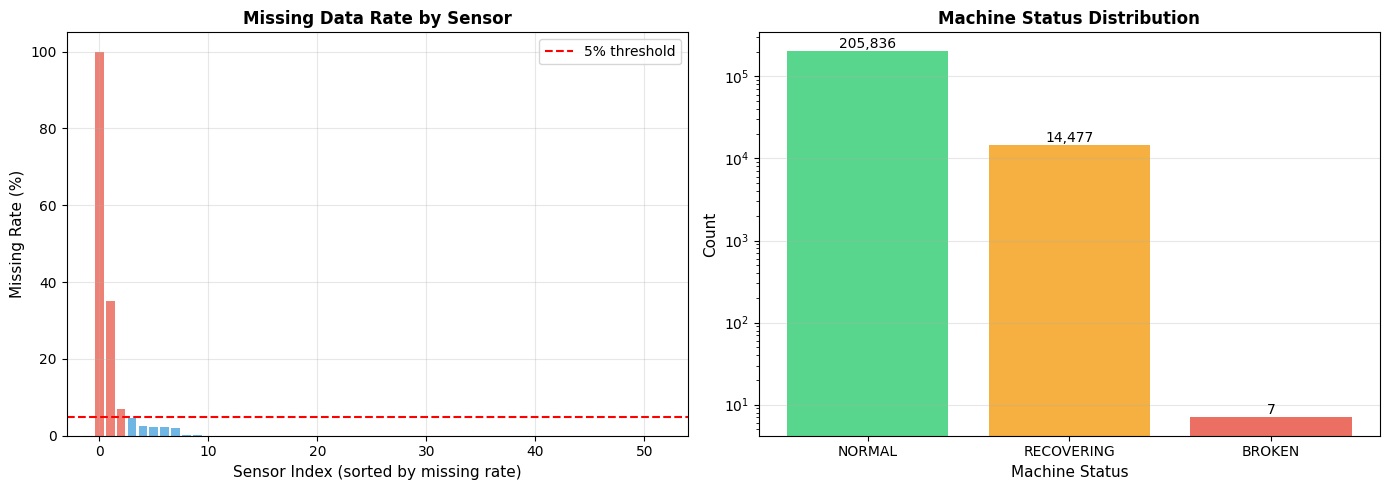


[시각화 해석]
  좌측: 센서별 결측치 비율 (빨간색: 5% 초과, 파란색: 5% 이하)
  우측: 기계 상태 분포 (로그 스케일) - BROKEN이 극히 희귀함을 확인


In [9]:
# 결측치 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 센서별 결측치 비율
ax1 = axes[0]
missing_pct_sorted = missing_pct[sensor_cols].sort_values(ascending=False)
colors = ['#e74c3c' if x > 5 else '#3498db' for x in missing_pct_sorted.values]
ax1.bar(range(len(missing_pct_sorted)), missing_pct_sorted.values, color=colors, alpha=0.7)
ax1.axhline(y=5, color='red', linestyle='--', label='5% threshold')
ax1.set_xlabel('Sensor Index (sorted by missing rate)', fontsize=11)
ax1.set_ylabel('Missing Rate (%)', fontsize=11)
ax1.set_title('Missing Data Rate by Sensor', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# machine_status 분포
ax2 = axes[1]
colors_status = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax2.bar(status_counts.index, status_counts.values, color=colors_status, alpha=0.8)
ax2.set_xlabel('Machine Status', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Machine Status Distribution', fontsize=12, fontweight='bold')
ax2.set_yscale('log')  # 로그 스케일로 불균형 시각화
for bar, count in zip(bars, status_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{count:,}', ha='center', va='bottom', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print("  좌측: 센서별 결측치 비율 (빨간색: 5% 초과, 파란색: 5% 이하)")
print("  우측: 기계 상태 분포 (로그 스케일) - BROKEN이 극히 희귀함을 확인")

## 1.6 데이터 전처리

클러스터링을 수행하기 전에 반드시 데이터 전처리가 필요함. 특히 결측치 처리와 스케일링이 중요함.

### 전처리가 필요한 이유

| 문제 | 영향 | 해결 방법 |
|:---:|:---|:---|
| **결측치** | 대부분의 알고리즘이 결측치를 처리하지 못함 | 제거 또는 대체(평균, 중앙값 등) |
| **스케일 차이** | 스케일이 큰 변수가 클러스터링에 과도한 영향 | 표준화(Standardization) |
| **고차원** | 차원의 저주, 계산 비용 증가 | 차원 축소(PCA 등) |

### 결측치 처리 전략

본 데이터에서는 다음 전략을 적용함:
1. 결측치가 과도하게 많은 센서(5% 초과)는 분석에서 제외
2. 나머지 센서의 결측치는 해당 센서의 중앙값으로 대체
3. 결측치가 있는 행이 여전히 많다면 해당 행 제거

In [10]:
# 전처리 수행
print("="*60)
print("[데이터 전처리 수행]")
print("="*60)

# Step 1: 결측치가 5% 초과인 센서 제외
threshold = 5.0
good_sensors = missing_pct[missing_pct <= threshold].index.tolist()
good_sensors = [s for s in good_sensors if s.startswith('sensor_')]
excluded_sensors = [s for s in sensor_cols if s not in good_sensors]

print(f"\nStep 1: 결측치 비율 기준 센서 필터링")
print(f"  - 결측치 임계값: {threshold}%")
print(f"  - 사용할 센서: {len(good_sensors)}개")
print(f"  - 제외된 센서: {len(excluded_sensors)}개")
if excluded_sensors:
    print(f"    {excluded_sensors}")

# Step 2: 사용할 센서만 선택
df_clean = df[good_sensors + ['machine_status', 'timestamp']].copy()

# Step 3: 중앙값으로 결측치 대체
print(f"\nStep 2: 중앙값으로 결측치 대체")
for col in good_sensors:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

# 결측치 확인
remaining_missing = df_clean[good_sensors].isnull().sum().sum()
print(f"  - 남은 결측치: {remaining_missing}개")

# Step 4: 샘플링 (계산 효율성을 위해)
# 전체 데이터가 22만건이므로, 클러스터링 실습을 위해 일부 샘플링
sample_size = 10000
print(f"\nStep 3: 데이터 샘플링")
print(f"  - 원본 데이터: {len(df_clean):,}건")

# 상태별 비율을 유지하며 샘플링 (층화 샘플링)
df_sample = df_clean.groupby('machine_status', group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(sample_size * len(x) / len(df_clean))), random_state=42)
)

# BROKEN 상태는 매우 적으므로 모두 포함
broken_data = df_clean[df_clean['machine_status'] == 'BROKEN']
df_sample = pd.concat([df_sample, broken_data]).drop_duplicates()

print(f"  - 샘플링 데이터: {len(df_sample):,}건")
print(f"\n[샘플링 후 상태 분포]")
print(df_sample['machine_status'].value_counts())

[데이터 전처리 수행]

Step 1: 결측치 비율 기준 센서 필터링
  - 결측치 임계값: 5.0%
  - 사용할 센서: 49개
  - 제외된 센서: 3개
    ['sensor_15', 'sensor_50', 'sensor_51']

Step 2: 중앙값으로 결측치 대체
  - 남은 결측치: 0개

Step 3: 데이터 샘플링
  - 원본 데이터: 220,320건
  - 샘플링 데이터: 10,006건

[샘플링 후 상태 분포]
machine_status
NORMAL        9342
RECOVERING     657
BROKEN           7
Name: count, dtype: int64


In [11]:
# 데이터 표준화
print("\n" + "="*60)
print("[데이터 표준화 (Standardization)]")
print("="*60)

# 센서 데이터만 추출
X = df_sample[good_sensors].values
y_status = df_sample['machine_status'].values

print(f"\n표준화 전 데이터 통계 (처음 5개 센서):")
print(f"  평균: {X[:, :5].mean(axis=0).round(2)}")
print(f"  표준편차: {X[:, :5].std(axis=0).round(2)}")

# 표준화 수행
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n표준화 후 데이터 통계 (처음 5개 센서):")
print(f"  평균: {X_scaled[:, :5].mean(axis=0).round(4)}")
print(f"  표준편차: {X_scaled[:, :5].std(axis=0).round(4)}")

print("\n[표준화의 중요성]")
print("  - 각 센서의 측정 단위와 범위가 다름")
print("  - 스케일이 큰 센서가 클러스터링에 과도한 영향을 미침")
print("  - 표준화 후 모든 센서가 동등한 기여를 하게 됨")


[데이터 표준화 (Standardization)]

표준화 전 데이터 통계 (처음 5개 센서):
  평균: [  2.38  47.57  50.86  43.73 590.4 ]
  표준편차: [  0.4    3.33   3.7    2.43 145.28]

표준화 후 데이터 통계 (처음 5개 센서):
  평균: [-0. -0.  0.  0. -0.]
  표준편차: [1. 1. 1. 1. 1.]

[표준화의 중요성]
  - 각 센서의 측정 단위와 범위가 다름
  - 스케일이 큰 센서가 클러스터링에 과도한 영향을 미침
  - 표준화 후 모든 센서가 동등한 기여를 하게 됨


### 전처리를 하지 않았을 경우의 문제점

**결측치를 처리하지 않은 경우:**

In [12]:
# 결측치 미처리 시 문제점 시연
print("[결측치 미처리 시 문제점]")
print("="*60)

# 결측치가 있는 원본 데이터로 클러스터링 시도
X_with_missing = df[sensor_cols].head(1000).values

print(f"결측치 포함 데이터: {np.isnan(X_with_missing).sum()}개의 NaN 값")

try:
    kmeans_test = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_test.fit(X_with_missing)
    print("클러스터링 성공")  # 이 줄은 실행되지 않음
except ValueError as e:
    print(f"\n오류 발생: {str(e)[:80]}...")
    print("\n=> K-Means는 결측치(NaN)가 있으면 동작하지 않음")
    print("   반드시 결측치를 처리한 후 클러스터링을 수행해야 함")

[결측치 미처리 시 문제점]
결측치 포함 데이터: 1000개의 NaN 값

오류 발생: Input X contains NaN.
KMeans does not accept missing values encoded as NaN nativ...

=> K-Means는 결측치(NaN)가 있으면 동작하지 않음
   반드시 결측치를 처리한 후 클러스터링을 수행해야 함


In [13]:
# 표준화 미적용 시 문제점 시연
print("\n[표준화 미적용 시 문제점]")
print("="*60)

# 스케일 차이가 큰 두 센서 선택
sensor_small = 'sensor_00'  # 평균 약 2.4
sensor_large = 'sensor_04'  # 평균 약 590

print(f"\n두 센서의 스케일 비교:")
print(f"  {sensor_small}: 평균={df_sample[sensor_small].mean():.2f}, 표준편차={df_sample[sensor_small].std():.2f}")
print(f"  {sensor_large}: 평균={df_sample[sensor_large].mean():.2f}, 표준편차={df_sample[sensor_large].std():.2f}")

# 유클리드 거리 계산 예시
point1 = np.array([df_sample[sensor_small].iloc[0], df_sample[sensor_large].iloc[0]])
point2 = np.array([df_sample[sensor_small].iloc[1], df_sample[sensor_large].iloc[1]])

# 표준화 전 거리
distance_raw = np.sqrt(np.sum((point1 - point2)**2))

# 각 센서의 기여도
contrib_small = (point1[0] - point2[0])**2
contrib_large = (point1[1] - point2[1])**2

print(f"\n유클리드 거리 분해:")
print(f"  {sensor_small} 기여: {contrib_small:.4f} ({contrib_small/(contrib_small+contrib_large)*100:.1f}%)")
print(f"  {sensor_large} 기여: {contrib_large:.4f} ({contrib_large/(contrib_small+contrib_large)*100:.1f}%)")
print(f"\n=> 스케일이 큰 센서가 거리 계산을 지배함")
print("   표준화를 통해 모든 센서가 균등하게 기여하도록 해야 함")


[표준화 미적용 시 문제점]

두 센서의 스케일 비교:
  sensor_00: 평균=2.38, 표준편차=0.40
  sensor_04: 평균=590.40, 표준편차=145.28

유클리드 거리 분해:
  sensor_00 기여: 0.0021 (0.0%)
  sensor_04 기여: 90.0738 (100.0%)

=> 스케일이 큰 센서가 거리 계산을 지배함
   표준화를 통해 모든 센서가 균등하게 기여하도록 해야 함


# 2. K-Means 클러스터링

## 2.1 K-Means 알고리즘 원리

K-Means는 **K개의 중심점(centroid)** 을 기준으로 데이터를 K개의 군집으로 분할하는 알고리즘임.

이 외에도, K 시리즈들은 전부 비스무리함(K-Nearest Neighborhood 등..)

### 핵심 아이디어

1. **각 데이터는 가장 가까운 중심점에 할당됨**
2. **중심점은 해당 군집의 평균 위치로 갱신됨**
3. **수렴할 때까지 (1)과 (2)를 반복함**

### 알고리즘 흐름

```mermaid
flowchart TD
    A["Step 1: 초기화<br/>K개 중심점 무작위 선택"] --> B["Step 2: 할당<br/>각 데이터를 가장 가까운 중심점에 배정"]
    B --> C["Step 3: 갱신<br/>각 군집의 평균으로 중심점 이동"]
    C --> D{"Step 4: 수렴 확인<br/>중심점 변화 있음?"}
    D -->|Yes| B
    D -->|No| E["종료<br/>최종 군집 결과 반환"]
```

### 알고리즘 단계별 상세 설명

| 단계 | 동작 | 수학적 표현 |
|:---:|:---|:---|
| **1. 초기화** | K개의 초기 중심점을 무작위로 선택 | $\mu_1, \mu_2, ..., \mu_k$ 초기화 |
| **2. 할당** | 각 데이터를 가장 가까운 중심점의 군집에 배정 | $C_i = \{x : \|x - \mu_i\| \leq \|x - \mu_j\|, \forall j\}$ |
| **3. 갱신** | 각 군집의 평균으로 중심점 재계산 | $\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$ |
| **4. 수렴** | 중심점 변화가 없으면 종료 | $\mu_i^{(t)} = \mu_i^{(t-1)}$ |

### K-Means의 특징

| 장점 | 단점 |
|:---|:---|
| 간단하고 직관적 | K를 미리 지정해야 함 |
| 계산 효율적 | 초기값에 민감 |
| 대용량 데이터에 적합 | 구형(spherical) 군집에 적합 |
| 해석이 용이 | 이상치에 민감 |

## 2.2 이론적 배경

### K-Means 목적함수 (WCSS: Within-Cluster Sum of Squares)

K-Means는 **군집 내 분산의 합(WCSS)** 을 최소화하는 것을 목표로 함.

$$\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

| 기호 | 의미 |
|:---:|:---|
| $k$ | 군집 개수 |
| $C_i$ | $i$번째 군집에 속한 데이터 집합 |
| $\mu_i$ | $i$번째 군집의 중심점 (군집 평균) |
| $\|x - \mu_i\|^2$ | 데이터 $x$와 중심점 $\mu_i$ 간 유클리드 거리의 제곱 |

### 유클리드 거리 (Euclidean Distance)

K-Means는 기본적으로 유클리드 거리를 사용하여 데이터 간 유사도를 측정함.

$$d(x, \mu) = \sqrt{\sum_{j=1}^{p}(x_j - \mu_j)^2}$$

| 기호 | 의미 |
|:---:|:---|
| $x$ | 데이터 포인트 (p차원 벡터) |
| $\mu$ | 군집 중심점 (p차원 벡터) |
| $p$ | 특성(변수) 개수 |
| $x_j$ | 데이터 $x$의 $j$번째 특성 값 |

### WCSS 실제 계산 예시

간단한 2차원 데이터로 WCSS를 직접 계산해보겠음.

**예시 데이터 (K=2 군집)**

| 군집 | 데이터 포인트 | 중심점 $\mu$ |
|:---:|:---|:---|
| $C_1$ | (1, 2), (2, 1), (2, 3) | (1.67, 2.0) |
| $C_2$ | (8, 8), (9, 7), (8, 9) | (8.33, 8.0) |

**군집 1의 거리 제곱 계산:**

$$
\begin{aligned}
d^2((1, 2), (1.67, 2.0)) &= (1 - 1.67)^2 + (2 - 2.0)^2 = 0.449 + 0 = 0.449 \\
d^2((2, 1), (1.67, 2.0)) &= (2 - 1.67)^2 + (1 - 2.0)^2 = 0.109 + 1.0 = 1.109 \\
d^2((2, 3), (1.67, 2.0)) &= (2 - 1.67)^2 + (3 - 2.0)^2 = 0.109 + 1.0 = 1.109 \\
\end{aligned}
$$

$$\sum_{x \in C_1} ||x - \mu_1||^2 = 0.449 + 1.109 + 1.109 = 2.667$$

**군집 2의 거리 제곱 계산:**

$$
\begin{aligned}
d^2((8, 8), (8.33, 8.0)) &= (8 - 8.33)^2 + (8 - 8.0)^2 = 0.109 + 0 = 0.109 \\
d^2((9, 7), (8.33, 8.0)) &= (9 - 8.33)^2 + (7 - 8.0)^2 = 0.449 + 1.0 = 1.449 \\
d^2((8, 9), (8.33, 8.0)) &= (8 - 8.33)^2 + (9 - 8.0)^2 = 0.109 + 1.0 = 1.109 \\
\end{aligned}
$$

$$\sum_{x \in C_2} ||x - \mu_2||^2 = 0.109 + 1.449 + 1.109 = 2.667$$

**최종 WCSS:**

$$\text{WCSS} = 2.667 + 2.667 = 5.334$$

In [14]:
# WCSS 계산 예시 코드
print("[WCSS 계산 예시]")
print("="*60)

# 예시 데이터
C1 = np.array([[1, 2], [2, 1], [2, 3]])
C2 = np.array([[8, 8], [9, 7], [8, 9]])

# 중심점 계산
mu1 = C1.mean(axis=0)
mu2 = C2.mean(axis=0)

print(f"군집 1 데이터: {C1.tolist()}")
print(f"군집 1 중심점: ({mu1[0]:.2f}, {mu1[1]:.2f})")
print(f"\n군집 2 데이터: {C2.tolist()}")
print(f"군집 2 중심점: ({mu2[0]:.2f}, {mu2[1]:.2f})")

# WCSS 계산
wcss_c1 = np.sum((C1 - mu1)**2)
wcss_c2 = np.sum((C2 - mu2)**2)
wcss_total = wcss_c1 + wcss_c2

print(f"\n군집 1 WCSS: {wcss_c1:.3f}")
print(f"군집 2 WCSS: {wcss_c2:.3f}")
print(f"총 WCSS: {wcss_total:.3f}")

[WCSS 계산 예시]
군집 1 데이터: [[1, 2], [2, 1], [2, 3]]
군집 1 중심점: (1.67, 2.00)

군집 2 데이터: [[8, 8], [9, 7], [8, 9]]
군집 2 중심점: (8.33, 8.00)

군집 1 WCSS: 2.667
군집 2 WCSS: 2.667
총 WCSS: 5.333


### 실루엣 점수 (Silhouette Score)

군집의 품질을 평가하는 지표로, 각 데이터가 **자신의 군집에 얼마나 잘 속해 있는지**를 측정함.

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

| 기호 | 의미 | 설명 |
|:---:|:---|:---|
| $a(i)$ | 응집도 (cohesion) | 같은 군집 내 다른 데이터들과의 평균 거리 |
| $b(i)$ | 분리도 (separation) | 가장 가까운 다른 군집의 데이터들과의 평균 거리 |

| 점수 범위 | 해석 |
|:---:|:---|
| 1에 가까움 | 데이터가 자신의 군집에 매우 잘 속해 있음 |
| 0 근처 | 군집 경계에 위치하여 어느 군집에도 애매함 |
| 음수 | 잘못된 군집에 배정되었을 가능성 높음 |

### 실루엣 점수 계산 예시

위 예시에서 포인트 $x_1 = (1, 2)$의 실루엣 점수를 계산함.

**Step 1: $a(x_1)$ 계산 (같은 군집 내 평균 거리)**

군집 $C_1$의 다른 점들: $(2, 1), (2, 3)$

$$
\begin{aligned}
d(x_1, (2,1)) &= \sqrt{(1-2)^2 + (2-1)^2} = \sqrt{2} \approx 1.414 \\
d(x_1, (2,3)) &= \sqrt{(1-2)^2 + (2-3)^2} = \sqrt{2} \approx 1.414 \\
\end{aligned}
$$

$$a(x_1) = \frac{1.414 + 1.414}{2} = 1.414$$

**Step 2: $b(x_1)$ 계산 (다른 군집과의 평균 거리)**

군집 $C_2$의 모든 점들: $(8, 8), (9, 7), (8, 9)$

$$
\begin{aligned}
d(x_1, (8,8)) &= \sqrt{(1-8)^2 + (2-8)^2} = \sqrt{49 + 36} \approx 9.22 \\
d(x_1, (9,7)) &= \sqrt{(1-9)^2 + (2-7)^2} = \sqrt{64 + 25} \approx 9.43 \\
d(x_1, (8,9)) &= \sqrt{(1-8)^2 + (2-9)^2} = \sqrt{49 + 49} \approx 9.90 \\
\end{aligned}
$$

$$b(x_1) = \frac{9.22 + 9.43 + 9.90}{3} = 9.52$$

**Step 3: 실루엣 점수 계산**

$$s(x_1) = \frac{b(x_1) - a(x_1)}{\max(a(x_1), b(x_1))} = \frac{9.52 - 1.414}{\max(1.414, 9.52)} = \frac{8.106}{9.52} \approx 0.85$$

**해석:** $s(x_1) = 0.85$로 1에 가까우므로, $x_1$은 자신의 군집($C_1$)에 매우 잘 배정되어 있음.

In [15]:
# 실루엣 점수 계산 예시 코드
print("[실루엣 점수 계산 예시]")
print("="*60)

# 데이터 포인트 x1 = (1, 2)
x1 = np.array([1, 2])

# a(x1): 같은 군집 내 평균 거리
distances_same = [np.sqrt(np.sum((x1 - p)**2)) for p in C1 if not np.array_equal(x1, p)]
a_x1 = np.mean(distances_same)

# b(x1): 다른 군집과의 평균 거리
distances_other = [np.sqrt(np.sum((x1 - p)**2)) for p in C2]
b_x1 = np.mean(distances_other)

# 실루엣 점수
s_x1 = (b_x1 - a_x1) / max(a_x1, b_x1)

print(f"데이터 포인트 x1: {x1}")
print(f"a(x1) - 군집 내 평균 거리: {a_x1:.3f}")
print(f"b(x1) - 다른 군집과의 평균 거리: {b_x1:.3f}")
print(f"실루엣 점수 s(x1): {s_x1:.3f}")
print(f"\n해석: 1에 가까우므로 x1은 군집 C1에 잘 배정되어 있음")

[실루엣 점수 계산 예시]
데이터 포인트 x1: [1 2]
a(x1) - 군집 내 평균 거리: 1.414
b(x1) - 다른 군집과의 평균 거리: 9.518
실루엣 점수 s(x1): 0.851

해석: 1에 가까우므로 x1은 군집 C1에 잘 배정되어 있음


## 2.3 최적 K 선택 방법

K-Means의 핵심 과제 중 하나는 **최적의 군집 개수 K를 결정**하는 것임. 두 가지 대표적인 방법을 소개함.

### 엘보우 방법 (Elbow Method)

- K가 증가하면 WCSS(Inertia)는 감소함
- 감소율이 급격히 줄어드는 지점("팔꿈치" 지점)을 최적 K로 선택
- 그래프에서 꺾이는 지점을 시각적으로 판단

### 실루엣 분석 (Silhouette Analysis)

- 각 K 값에 대해 평균 실루엣 점수 계산
- 점수가 가장 높은 K를 선택
- 더 객관적인 기준 제공

| 방법 | 기준 | 장점 | 단점 |
|:---:|:---|:---|:---|
| **엘보우** | WCSS 감소율 변곡점 | 직관적, 시각화 용이 | 주관적 판단 필요 |
| **실루엣** | 평균 실루엣 점수 최대화 | 객관적 수치 기준 | 계산 비용 높음 |

## 2.4 실습: K-Means 클러스터링

실제 펌프 센서 데이터에 K-Means를 적용해보겠음.

In [17]:
# 엘보우 방법으로 최적 K 탐색
print("[엘보우 방법 - 최적 K 탐색]")
print("="*60)

# 다양한 K 값에 대해 Inertia(WCSS) 계산
k_range = range(2, 12)
inertias = []
silhouette_scores = []

print("\nK 값별 Inertia 계산 중...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    # 실루엣 점수 계산
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    
    print(f"K={k:2}: Inertia={kmeans.inertia_:>12,.0f}, Silhouette={sil_score:.4f}")

# 최적 K 찾기
best_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
print(f"\n실루엣 점수 기준 최적 K: {best_k_silhouette}")

[엘보우 방법 - 최적 K 탐색]

K 값별 Inertia 계산 중...
K= 2: Inertia=     326,847, Silhouette=0.5423
K= 3: Inertia=     252,976, Silhouette=0.5640
K= 4: Inertia=     227,482, Silhouette=0.2309
K= 5: Inertia=     208,239, Silhouette=0.2351
K= 6: Inertia=     190,836, Silhouette=0.2437
K= 7: Inertia=     179,913, Silhouette=0.2523
K= 8: Inertia=     169,535, Silhouette=0.2127
K= 9: Inertia=     162,430, Silhouette=0.2059
K=10: Inertia=     155,158, Silhouette=0.1968
K=11: Inertia=     147,819, Silhouette=0.1992

실루엣 점수 기준 최적 K: 3


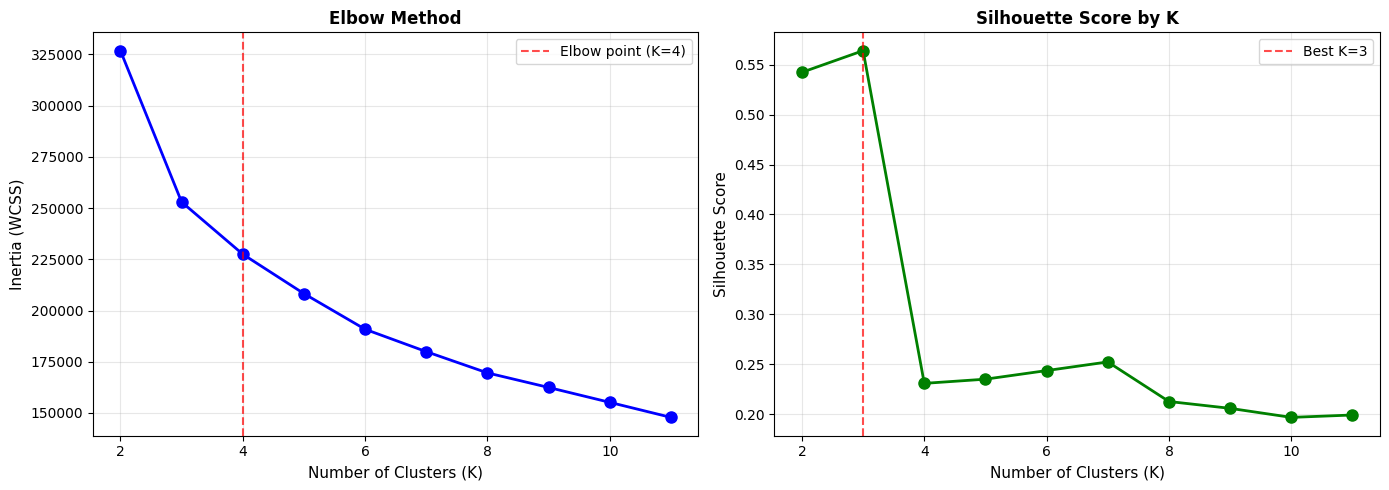


[시각화 해석]
  엘보우 방법: K=4 지점에서 Inertia 감소율이 급격히 줄어듦
  실루엣 분석: K=3에서 최고 점수 달성
  두 방법을 종합하여 최적 K를 결정함


In [18]:
# 엘보우 및 실루엣 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 엘보우 그래프
ax1 = axes[0]
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Inertia 감소율 계산하여 엘보우 포인트 표시
inertia_diff = np.diff(inertias)
inertia_diff2 = np.diff(inertia_diff)
elbow_idx = np.argmax(inertia_diff2) + 2  # 2번째 미분 최대 지점
elbow_k = list(k_range)[elbow_idx]
ax1.axvline(x=elbow_k, color='r', linestyle='--', alpha=0.7, label=f'Elbow point (K={elbow_k})')
ax1.legend()

# 실루엣 점수 그래프
ax2 = axes[1]
ax2.plot(list(k_range), silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=best_k_silhouette, color='r', linestyle='--', alpha=0.7, 
            label=f'Best K={best_k_silhouette}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score by K', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print(f"  엘보우 방법: K={elbow_k} 지점에서 Inertia 감소율이 급격히 줄어듦")
print(f"  실루엣 분석: K={best_k_silhouette}에서 최고 점수 달성")
print(f"  두 방법을 종합하여 최적 K를 결정함")

In [19]:
# 최적 K로 K-Means 수행
print("\n[최적 K로 K-Means 클러스터링 수행]")
print("="*60)

# K=3으로 결정 (제조 도메인 지식 반영: NORMAL, RECOVERING, BROKEN 3개 상태)
optimal_k = 3
print(f"\n선택된 K: {optimal_k}")
print("  (실루엣 점수와 도메인 지식을 종합하여 결정)")

# K-Means 모델 학습
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

labels = kmeans_final.fit_predict(X_scaled)
centers = kmeans_final.cluster_centers_

print(f"\n[클러스터링 결과]")
print(f"  반복 횟수: {kmeans_final.n_iter_}")
print(f"  최종 Inertia: {kmeans_final.inertia_:,.0f}")
print(f"  실루엣 점수: {silhouette_score(X_scaled, labels):.4f}")

print(f"\n[군집별 데이터 수]")
for i in range(optimal_k):
    count = (labels == i).sum()
    pct = count / len(labels) * 100
    print(f"  Cluster {i}: {count:,}건 ({pct:.1f}%)")


[최적 K로 K-Means 클러스터링 수행]

선택된 K: 3
  (실루엣 점수와 도메인 지식을 종합하여 결정)

[클러스터링 결과]
  반복 횟수: 8
  최종 Inertia: 252,976
  실루엣 점수: 0.5640

[군집별 데이터 수]
  Cluster 0: 733건 (7.3%)
  Cluster 1: 8,203건 (82.0%)
  Cluster 2: 1,070건 (10.7%)


In [20]:
# 군집 결과와 실제 machine_status 비교
print("\n[군집 결과 vs 실제 기계 상태 교차표]")
print("="*60)

# 교차표 생성
comparison_df = pd.DataFrame({
    'Cluster': labels,
    'Actual_Status': y_status
})

crosstab = pd.crosstab(
    comparison_df['Cluster'], 
    comparison_df['Actual_Status'],
    margins=True
)

print(crosstab)

print("\n[해석]")
print("  - 비지도학습은 레이블 없이 데이터의 내재적 구조를 발견")
print("  - 발견된 군집이 실제 기계 상태와 얼마나 일치하는지 확인")
print("  - 군집 번호와 실제 상태의 순서는 일치하지 않을 수 있음")


[군집 결과 vs 실제 기계 상태 교차표]
Actual_Status  BROKEN  NORMAL  RECOVERING    All
Cluster                                         
0                   2      87         644    733
1                   4    8186          13   8203
2                   1    1069           0   1070
All                 7    9342         657  10006

[해석]
  - 비지도학습은 레이블 없이 데이터의 내재적 구조를 발견
  - 발견된 군집이 실제 기계 상태와 얼마나 일치하는지 확인
  - 군집 번호와 실제 상태의 순서는 일치하지 않을 수 있음



[클러스터링 결과 시각화 (PCA 2D)]

PCA 설명 분산비:
  PC1: 35.63%
  PC2: 18.80%
  합계: 54.43%


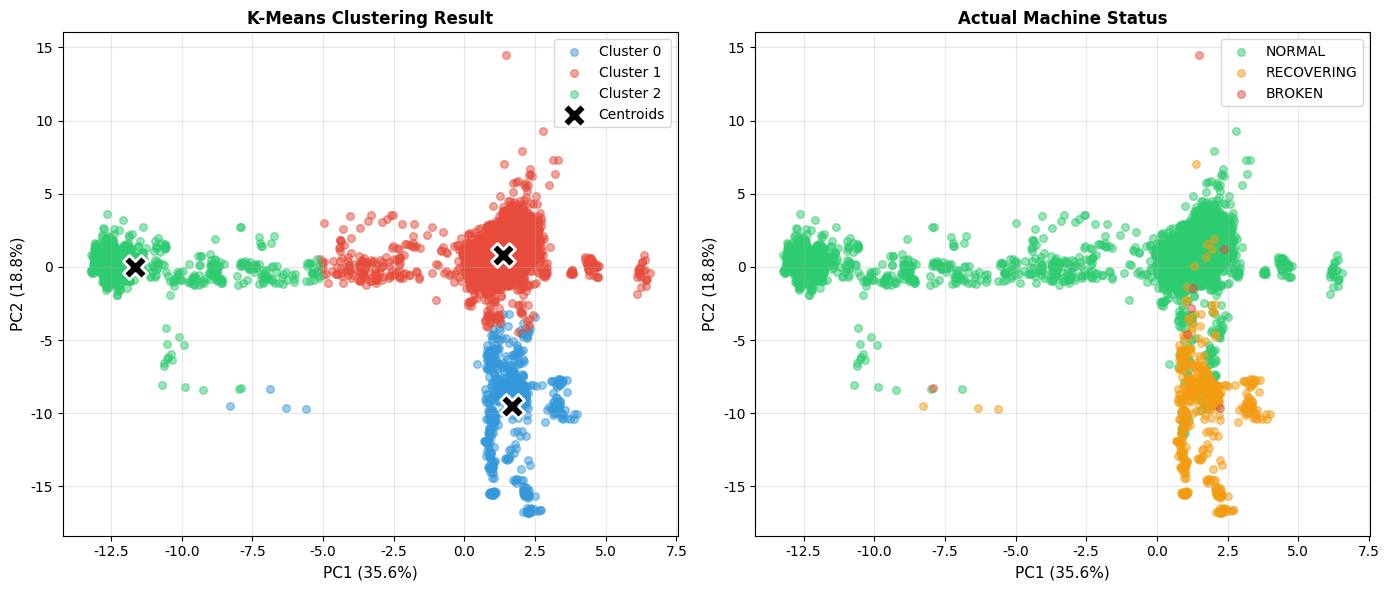


[시각화 해석]
  좌측: K-Means가 발견한 3개 군집과 중심점 위치
  우측: 실제 기계 상태별 분포 (검증용)
  PCA로 52차원 데이터를 2차원으로 압축하여 시각화


In [21]:
# PCA를 사용한 2D 시각화
print("\n[클러스터링 결과 시각화 (PCA 2D)]")
print("="*60)

# PCA로 2차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(centers)

print(f"\nPCA 설명 분산비:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  합계: {sum(pca.explained_variance_ratio_):.2%}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means 군집 결과
ax1 = axes[0]
colors = ['#3498db', '#e74c3c', '#2ecc71']
for i in range(optimal_k):
    mask = labels == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], 
                label=f'Cluster {i}', alpha=0.5, s=30)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', 
            marker='X', s=300, edgecolors='white', linewidths=2, 
            label='Centroids', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('K-Means Clustering Result', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 실제 기계 상태
ax2 = axes[1]
status_colors = {'NORMAL': '#2ecc71', 'RECOVERING': '#f39c12', 'BROKEN': '#e74c3c'}
for status in ['NORMAL', 'RECOVERING', 'BROKEN']:
    mask = y_status == status
    if mask.sum() > 0:
        ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=status_colors[status], 
                    label=status, alpha=0.5, s=30)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Actual Machine Status', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print("  좌측: K-Means가 발견한 3개 군집과 중심점 위치")
print("  우측: 실제 기계 상태별 분포 (검증용)")
print("  PCA로 52차원 데이터를 2차원으로 압축하여 시각화")

In [22]:
# 군집 중심점 분석 (원본 스케일)
print("\n[군집 중심점 분석]")
print("="*60)

# 표준화된 중심점을 원본 스케일로 역변환
centers_original = scaler.inverse_transform(centers)

# 중심점 DataFrame 생성
centers_df = pd.DataFrame(centers_original, columns=good_sensors)
centers_df.index = [f'Cluster {i}' for i in range(optimal_k)]

# 주요 센서만 출력 (처음 10개)
print("\n군집 중심점 (처음 10개 센서, 원본 스케일):")
print(centers_df.iloc[:, :10].round(2).T)

# 군집 간 중심점 차이가 큰 센서 찾기
center_std = centers_df.std()
top_diff_sensors = center_std.nlargest(10)

print("\n군집 간 차이가 큰 센서 Top 10:")
for sensor, std in top_diff_sensors.items():
    values = centers_df[sensor].values
    print(f"  {sensor}: 표준편차={std:.2f}, 군집별 값={values.round(2)}")


[군집 중심점 분석]

군집 중심점 (처음 10개 센서, 원본 스케일):
           Cluster 0  Cluster 1  Cluster 2
sensor_00       1.63       2.44       2.42
sensor_01      39.84      48.31      47.22
sensor_02      40.32      51.64      52.14
sensor_03      37.98      44.16      44.36
sensor_04     107.82     629.63     620.28
sensor_05      44.83      75.61      76.10
sensor_06       8.35      13.98      13.38
sensor_07      11.46      16.22      16.10
sensor_08      11.29      15.53      15.34
sensor_09      10.98      15.13      15.02

군집 간 차이가 큰 센서 Top 10:
  sensor_23: 표준편차=523.78, 군집별 값=[1030.17 1017.11  116.49]
  sensor_28: 표준편차=516.71, 군집별 값=[1092.43  922.94  124.84]
  sensor_31: 표준편차=455.27, 군집별 값=[1022.59  937.13  194.8 ]
  sensor_26: 표준편차=426.05, 군집별 값=[860.68 865.99 125.4 ]
  sensor_32: 표준편차=422.12, 군집별 값=[928.53 875.78 172.46]
  sensor_21: 표준편차=412.61, 군집별 값=[870.99 871.91 156.79]
  sensor_25: 표준편차=394.61, 군집별 값=[716.9  722.83  36.4 ]
  sensor_19: 표준편차=363.26, 군집별 값=[659.06 657.3   28.99]
  sensor_24: 

# 3. 클러스터링 기반 이상 탐지 (8분)


## 3.1 이상 탐지의 개념

### 이상 탐지(Anomaly Detection)란?

**정상 패턴에서 벗어난 이상 데이터(anomaly)** 를 자동으로 찾아내는 기법임. 제조업에서는 설비 고장 예방, 품질 이상 조기 발견 등에 핵심적으로 활용됨.

| 용어 | 정의 | 제조업 예시 |
|:---:|:---|:---|
| **이상치 (Anomaly)** | 정상 패턴에서 벗어난 데이터 | 비정상 진동, 온도 급등 |
| **정상 (Normal)** | 일반적인 패턴의 데이터 | 정상 운전 조건 범위 내 |
| **이상 탐지** | 이상치를 자동으로 찾는 기법 | 설비 이상 조기 경보 시스템 |

### 제조업에서 이상 탐지가 중요한 이유

```
[예방 정비(Predictive Maintenance) 관점]

  기존 방식: 주기적 점검 또는 고장 후 수리
  ┌─────────────────────────────────────────────────┐
  │  정상 → 정상 → 정상 → [고장 발생!] → 긴급 수리  │
  │                              ↑                  │
  │                        예측 불가능              │
  └─────────────────────────────────────────────────┘

  이상 탐지 방식: 이상 징후 조기 발견
  ┌─────────────────────────────────────────────────┐
  │  정상 → 정상 → [이상 감지] → 예방 정비 → 정상   │
  │                     ↑                          │
  │              조기 경보로 고장 예방              │
  └─────────────────────────────────────────────────┘
```

### 클러스터링 기반 이상 탐지 원리

**핵심 아이디어:** 군집 중심에서 멀리 떨어진 데이터를 이상치로 판별함.

```
정상 데이터 군집:
        o o o
      o   X   o    X = 군집 중심
        o o o

                   * = 이상치 후보 (중심에서 멀리 떨어짐)
                *
```

- 정상 데이터는 군집 중심 근처에 밀집
- 이상 데이터는 군집 중심에서 멀리 위치
- 거리 임계값을 설정하여 이상치 판별

## 3.2 거리 기반 이상 탐지 프로세스

```mermaid
flowchart TD
    A["1. 데이터 수집 및 전처리"] --> B["2. 데이터 표준화"]
    B --> C["3. K-Means 군집화"]
    C --> D["4. 각 데이터와 군집 중심 간 거리 계산"]
    D --> E["5. 거리 분포 분석"]
    E --> F["6. 임계값 설정 (예: 95 percentile)"]
    F --> G{"7. 거리 > 임계값?"}
    G -->|Yes| H["이상치로 판별"]
    G -->|No| I["정상으로 판별"]
    H --> J["8. 결과 분석 및 조치"]
    I --> J
```

### 임계값 선택 가이드

| Percentile | 예상 이상치 비율 | 용도 | 특징 |
|:---:|:---:|:---|:---|
| 90% | 약 10% | 민감한 탐지 | 많은 이상치 탐지, 오탐 가능성 높음 |
| 95% | 약 5% | 일반적 기준 | 균형잡힌 탐지, 실무에서 자주 사용 |
| 97% | 약 3% | 보수적 탐지 | 심각한 이상만 탐지 |
| 99% | 약 1% | 매우 보수적 | 극단적 이상만 탐지, 놓치는 경우 있음 |

## 3.3 실습: 클러스터링 기반 이상 탐지

In [23]:
# 거리 계산 함수 정의
def calculate_distance_to_centroid(X, labels, centers):
    """
    각 데이터와 해당 군집 중심 간 유클리드 거리 계산
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        입력 데이터
    labels : array-like, shape (n_samples,)
        각 데이터의 군집 레이블
    centers : array-like, shape (n_clusters, n_features)
        군집 중심점
    
    Returns:
    --------
    distances : array, shape (n_samples,)
        각 데이터의 군집 중심까지 거리
    """
    distances = np.zeros(len(X))
    for i, (x, label) in enumerate(zip(X, labels)):
        centroid = centers[label]
        distances[i] = np.sqrt(np.sum((x - centroid) ** 2))
    return distances

print("[거리 계산 함수 정의 완료]")

[거리 계산 함수 정의 완료]


In [24]:
# 각 데이터와 군집 중심 간 거리 계산
print("\n[거리 기반 이상 탐지]")
print("="*60)

distances = calculate_distance_to_centroid(X_scaled, labels, centers)

print(f"\n거리 통계:")
print(f"  평균 거리: {distances.mean():.3f}")
print(f"  표준편차: {distances.std():.3f}")
print(f"  최소 거리: {distances.min():.3f}")
print(f"  최대 거리: {distances.max():.3f}")
print(f"  중앙값: {np.median(distances):.3f}")

# Percentile 확인
print(f"\nPercentile 값:")
for pct in [90, 95, 97, 99]:
    print(f"  {pct}%: {np.percentile(distances, pct):.3f}")


[거리 기반 이상 탐지]

거리 통계:
  평균 거리: 4.259
  표준편차: 2.673
  최소 거리: 1.315
  최대 거리: 66.670
  중앙값: 3.571

Percentile 값:
  90%: 6.882
  95%: 8.275
  97%: 10.460
  99%: 12.558


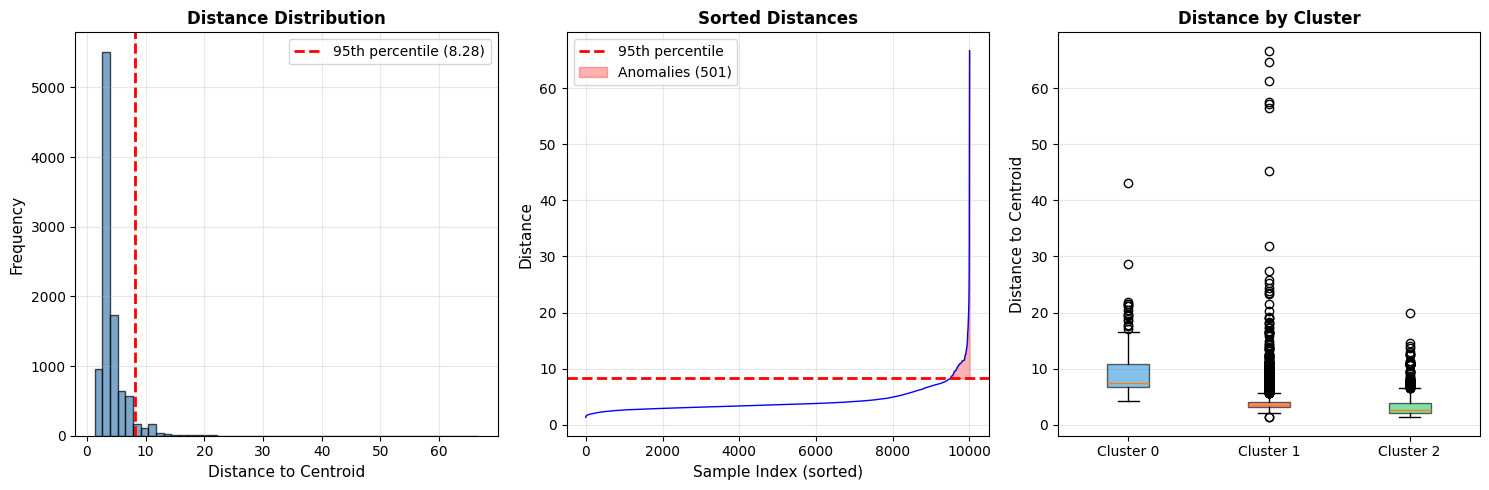


[시각화 해석]
  좌측: 거리 분포 - 오른쪽 꼬리가 이상치 후보
  중앙: 정렬된 거리 - 상위 5%가 이상치로 판별
  우측: 군집별 거리 박스플롯 - 이상치가 많은 군집 파악


In [25]:
# 거리 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 히스토그램
ax1 = axes[0]
ax1.hist(distances, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
threshold_95 = np.percentile(distances, 95)
ax1.axvline(x=threshold_95, color='r', linestyle='--', linewidth=2, 
            label=f'95th percentile ({threshold_95:.2f})')
ax1.set_xlabel('Distance to Centroid', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distance Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 정렬된 거리 그래프
ax2 = axes[1]
sorted_distances = np.sort(distances)
ax2.plot(sorted_distances, 'b-', linewidth=1)
ax2.axhline(y=threshold_95, color='r', linestyle='--', linewidth=2, 
            label=f'95th percentile')
anomaly_count = (distances > threshold_95).sum()
ax2.fill_between(range(len(sorted_distances) - anomaly_count, len(sorted_distances)),
                  sorted_distances[-anomaly_count:], threshold_95, 
                  color='red', alpha=0.3, label=f'Anomalies ({anomaly_count})')
ax2.set_xlabel('Sample Index (sorted)', fontsize=11)
ax2.set_ylabel('Distance', fontsize=11)
ax2.set_title('Sorted Distances', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 군집별 거리 박스플롯
ax3 = axes[2]
distance_by_cluster = [distances[labels == i] for i in range(optimal_k)]
bp = ax3.boxplot(distance_by_cluster, labels=[f'Cluster {i}' for i in range(optimal_k)],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax3.set_ylabel('Distance to Centroid', fontsize=11)
ax3.set_title('Distance by Cluster', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print("  좌측: 거리 분포 - 오른쪽 꼬리가 이상치 후보")
print("  중앙: 정렬된 거리 - 상위 5%가 이상치로 판별")
print("  우측: 군집별 거리 박스플롯 - 이상치가 많은 군집 파악")

In [26]:
# 이상 탐지 수행 (95 percentile 기준)
print("\n[이상 탐지 수행]")
print("="*60)

# 임계값 설정
threshold = np.percentile(distances, 95)
is_anomaly = distances > threshold

print(f"\n임계값 (95th percentile): {threshold:.3f}")
print(f"\n탐지 결과:")
print(f"  정상 데이터: {(~is_anomaly).sum():,}건 ({(~is_anomaly).mean():.1%})")
print(f"  이상 데이터: {is_anomaly.sum():,}건 ({is_anomaly.mean():.1%})")


[이상 탐지 수행]

임계값 (95th percentile): 8.275

탐지 결과:
  정상 데이터: 9,505건 (95.0%)
  이상 데이터: 501건 (5.0%)


In [27]:
# 이상 탐지 결과와 실제 기계 상태 비교
print("\n[이상 탐지 결과 vs 실제 기계 상태]")
print("="*60)

# 결과 DataFrame 생성
result_df = pd.DataFrame({
    'Distance': distances,
    'Cluster': labels,
    'Predicted_Anomaly': is_anomaly.astype(int),
    'Actual_Status': y_status
})

# 교차표 생성
crosstab_anomaly = pd.crosstab(
    result_df['Actual_Status'],
    result_df['Predicted_Anomaly'],
    margins=True
)
crosstab_anomaly.columns = ['Normal', 'Anomaly', 'Total']

print("\n예측 결과 교차표:")
print(crosstab_anomaly)

# 상태별 이상 탐지율
print("\n상태별 이상 탐지율:")
for status in ['NORMAL', 'RECOVERING', 'BROKEN']:
    mask = result_df['Actual_Status'] == status
    if mask.sum() > 0:
        anomaly_rate = result_df.loc[mask, 'Predicted_Anomaly'].mean() * 100
        print(f"  {status:12}: {anomaly_rate:>6.2f}% (탐지 {result_df.loc[mask, 'Predicted_Anomaly'].sum():,}건 / 전체 {mask.sum():,}건)")


[이상 탐지 결과 vs 실제 기계 상태]

예측 결과 교차표:
               Normal  Anomaly  Total
Actual_Status                        
BROKEN              3        4      7
NORMAL           9108      234   9342
RECOVERING        394      263    657
All              9505      501  10006

상태별 이상 탐지율:
  NORMAL      :   2.50% (탐지 234건 / 전체 9,342건)
  RECOVERING  :  40.03% (탐지 263건 / 전체 657건)
  BROKEN      :  57.14% (탐지 4건 / 전체 7건)


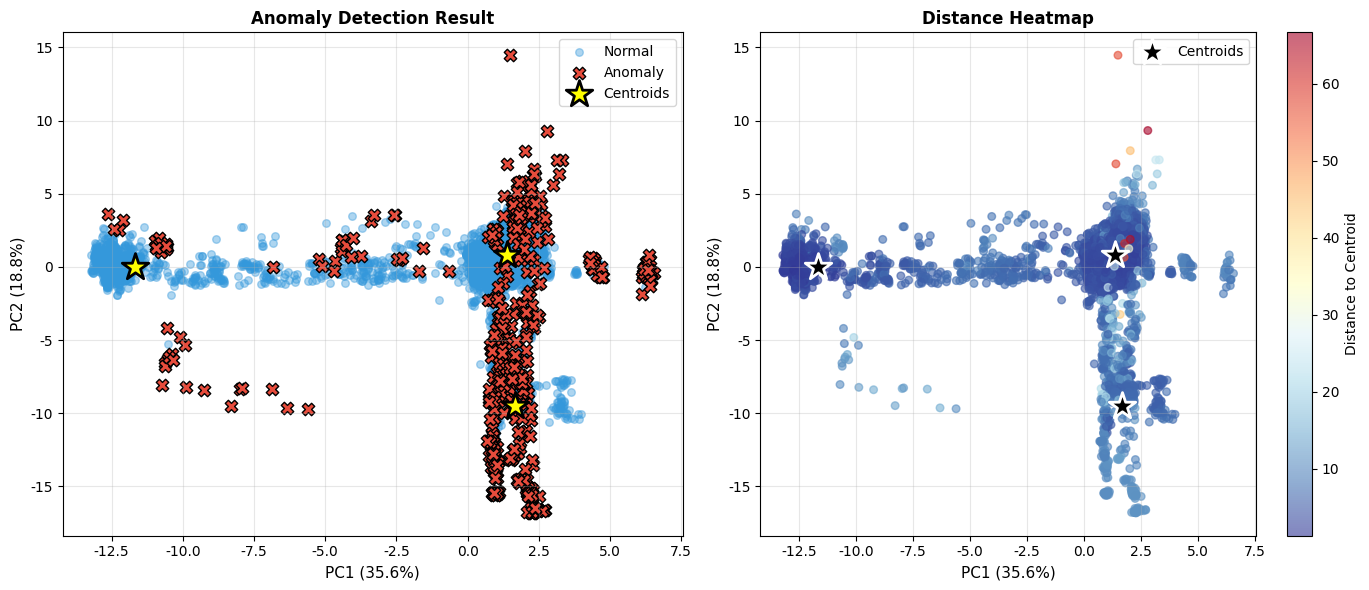


[시각화 해석]
  좌측: 이상치(빨간 X)가 군집 외곽에 위치하는지 확인
  우측: 거리 히트맵 - 군집 중심에서 멀수록 빨간색


In [28]:
# 이상 탐지 결과 시각화 (PCA 2D)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 이상/정상 분류 결과
ax1 = axes[0]
normal_mask = ~is_anomaly
ax1.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='#3498db', alpha=0.4, s=30, label='Normal')
ax1.scatter(X_pca[is_anomaly, 0], X_pca[is_anomaly, 1],
            c='#e74c3c', marker='X', s=80, edgecolors='black',
            linewidths=1, label='Anomaly')
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], c='yellow',
            marker='*', s=400, edgecolors='black', linewidths=2,
            label='Centroids', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('Anomaly Detection Result', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 거리 히트맵
ax2 = axes[1]
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=distances, 
                       cmap='RdYlBu_r', alpha=0.6, s=30)
ax2.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black',
            marker='*', s=400, edgecolors='white', linewidths=2,
            label='Centroids', zorder=5)
plt.colorbar(scatter, ax=ax2, label='Distance to Centroid')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Distance Heatmap', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print("  좌측: 이상치(빨간 X)가 군집 외곽에 위치하는지 확인")
print("  우측: 거리 히트맵 - 군집 중심에서 멀수록 빨간색")

In [29]:
# 다양한 임계값 비교
print("\n[다양한 임계값 비교]")
print("="*60)

percentiles = [90, 95, 97, 99]

print(f"\n{'Percentile':>12} | {'Threshold':>10} | {'Anomalies':>10} | {'Ratio':>8} | BROKEN 탐지율")
print("-" * 70)

for pct in percentiles:
    thresh = np.percentile(distances, pct)
    pred_anomaly = distances > thresh
    n_anomaly = pred_anomaly.sum()
    ratio = n_anomaly / len(distances) * 100
    
    # BROKEN 상태 탐지율
    broken_mask = result_df['Actual_Status'] == 'BROKEN'
    if broken_mask.sum() > 0:
        broken_detection = (pred_anomaly & broken_mask.values).sum() / broken_mask.sum() * 100
    else:
        broken_detection = 0
    
    print(f"{pct:>12}% | {thresh:>10.3f} | {n_anomaly:>10,} | {ratio:>7.1f}% | {broken_detection:>10.1f}%")

print("-" * 70)
print("\n[임계값 선택 가이드]")
print("  - 민감한 탐지가 필요하면 90% 사용 (오탐 증가)")
print("  - 일반적인 경우 95% 사용 (균형잡힌 탐지)")
print("  - 심각한 이상만 탐지하려면 99% 사용 (놓치는 경우 있음)")
print("  - 실무에서는 도메인 지식과 비용을 고려하여 조정")


[다양한 임계값 비교]

  Percentile |  Threshold |  Anomalies |    Ratio | BROKEN 탐지율
----------------------------------------------------------------------
          90% |      6.882 |      1,001 |    10.0% |       57.1%
          95% |      8.275 |        501 |     5.0% |       57.1%
          97% |     10.460 |        301 |     3.0% |       57.1%
          99% |     12.558 |        101 |     1.0% |       28.6%
----------------------------------------------------------------------

[임계값 선택 가이드]
  - 민감한 탐지가 필요하면 90% 사용 (오탐 증가)
  - 일반적인 경우 95% 사용 (균형잡힌 탐지)
  - 심각한 이상만 탐지하려면 99% 사용 (놓치는 경우 있음)
  - 실무에서는 도메인 지식과 비용을 고려하여 조정


In [30]:
# 이상치 샘플 상세 분석
print("\n[이상치 샘플 상세 분석]")
print("="*60)

# 거리가 가장 큰 이상치 Top 10
anomaly_indices = np.where(is_anomaly)[0]
anomaly_distances = distances[is_anomaly]
top_anomaly_idx = anomaly_indices[np.argsort(anomaly_distances)[-10:][::-1]]

print("\n거리가 가장 큰 이상치 Top 10:")
print(f"{'Index':>8} | {'Distance':>10} | {'Cluster':>8} | {'Actual Status':>15}")
print("-" * 50)

for idx in top_anomaly_idx:
    dist = distances[idx]
    cluster = labels[idx]
    status = y_status[idx]
    print(f"{idx:>8} | {dist:>10.3f} | {cluster:>8} | {status:>15}")


[이상치 샘플 상세 분석]

거리가 가장 큰 이상치 Top 10:
   Index |   Distance |  Cluster |   Actual Status
--------------------------------------------------
    7968 |     66.670 |        1 |          NORMAL
    9843 |     64.683 |        1 |      RECOVERING
    9536 |     61.323 |        1 |      RECOVERING
    9721 |     57.538 |        1 |      RECOVERING
   10002 |     57.126 |        1 |          BROKEN
    9541 |     56.471 |        1 |      RECOVERING
    6796 |     45.163 |        1 |          NORMAL
    9634 |     43.058 |        0 |      RECOVERING
    9995 |     31.904 |        1 |      RECOVERING
    9540 |     28.727 |        0 |      RECOVERING


In [ ]:
# 이상치의 센서 값 분석
print("\n[이상치 센서 값 분석]")
print("="*60)

# 정상 데이터와 이상 데이터의 센서별 평균 비교
normal_data = df_sample.loc[~is_anomaly, good_sensors]
anomaly_data = df_sample.loc[is_anomaly, good_sensors]

normal_mean = normal_data.mean()
anomaly_mean = anomaly_data.mean()

# 차이가 큰 센서 찾기
diff = abs(anomaly_mean - normal_mean)
diff_pct = (diff / normal_mean * 100).replace([np.inf, -np.inf], np.nan).dropna()
top_diff = diff_pct.nlargest(10)

print("\n정상/이상 데이터 간 차이가 큰 센서 Top 10:")
print(f"{'Sensor':>12} | {'Normal Mean':>12} | {'Anomaly Mean':>12} | {'Diff %':>10}")
print("-" * 55)

for sensor in top_diff.index:
    n_mean = normal_mean[sensor]
    a_mean = anomaly_mean[sensor]
    d_pct = diff_pct[sensor]
    print(f"{sensor:>12} | {n_mean:>12.2f} | {a_mean:>12.2f} | {d_pct:>9.1f}%")

print("\n[해석]")
print("  - 위 센서들이 이상 데이터에서 정상과 크게 다른 값을 보임")
print("  - 이상 탐지 시 이 센서들을 집중적으로 모니터링하면 효과적")

# 핵심 정리

## 비지도학습 핵심 개념

| 개념 | 설명 |
|:---:|:---|
| **비지도학습** | 레이블 없이 데이터의 내재적 패턴/구조 발견 |
| **군집화** | 유사한 데이터를 그룹으로 묶는 기법 |
| **K-Means** | K개 중심점 기반 군집화 알고리즘 |
| **이상 탐지** | 정상 패턴에서 벗어난 데이터 자동 탐지 |

## 주요 수식

| 수식 | 용도 |
|:---|:---|
| $\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$ | K-Means 목적함수 |
| $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$ | 실루엣 점수 |
| $d(x, \mu) = \sqrt{\sum_{j=1}^{p}(x_j - \mu_j)^2}$ | 유클리드 거리 |

## 최적 K 선택 방법

| 방법 | 기준 | 특징 |
|:---:|:---|:---|
| **엘보우 방법** | WCSS 감소율 변곡점 | 직관적, 시각적 판단 |
| **실루엣 분석** | 평균 실루엣 점수 최대화 | 객관적 수치 기준 |

## sklearn 패턴

```python
# K-Means 클러스터링 기본 패턴
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. 전처리 (표준화)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 군집화
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# 3. 평가
centers = kmeans.cluster_centers_
inertia = kmeans.inertia_
sil_score = silhouette_score(X_scaled, labels)

# 4. 이상 탐지 (거리 기반)
distances = [np.sqrt(np.sum((x - centers[l])**2)) 
             for x, l in zip(X_scaled, labels)]
threshold = np.percentile(distances, 95)
is_anomaly = distances > threshold
```

### 관련 알고리즘 (심화 학습용)
- DBSCAN: 밀도 기반 군집화, 노이즈에 강건
- Isolation Forest: 트리 기반 이상 탐지
- LOF (Local Outlier Factor): 밀도 기반 이상 탐지
- One-Class SVM: 정상 데이터만으로 이상 탐지 모델 학습

# 추가 보충. PCA에 관해서..

# 부록: PCA와 차원 축소

 16차시 본 강의에서 클러스터링 결과 시각화에 사용된 **PCA(Principal Component Analysis, 주성분 분석)** 의 개념과 **차원 축소(Dimensionality Reduction)** 의 원리를 보충함. 심화 과정 및 이해를 위해서 한번 읽어보기를 권장함
 
 **이론적 배경이 너무 복잡하다면, A.1절과 A.5절만 봐도 무방**함. 전체적으로 어떤 흐름으로 이 기법을 사용해야 하는지..에 대해서 확인할 것

## A.1 차원 축소의 필요성

### A.1.1 차원의 저주 (Curse of Dimensionality)

고차원 데이터에서 발생하는 여러 문제를 통칭하는 개념임.

```
[2차원 공간]                    [고차원 공간]
                               
  o   o                         데이터가 희박하게 분포
    o                           거리 개념이 무의미해짐
  o   o                         계산 비용 급증
                               
  => 데이터 밀집                 => "빈 공간"이 대부분
```

| 문제 | 설명 | 영향 |
|:---:|:---|:---|
| **데이터 희소성** | 고차원에서는 데이터가 공간에 희박하게 분포 | 군집화, 분류 성능 저하 |
| **거리 무의미화** | 모든 데이터 간 거리가 비슷해짐 | K-Means 등 거리 기반 알고리즘 성능 저하 |
| **계산 비용 증가** | 변수 수에 따라 연산량 기하급수적 증가 | 학습 시간 증가, 메모리 부족 |
| **과적합 위험** | 샘플 대비 변수가 많으면 노이즈 학습 | 일반화 성능 저하 |

### A.1.2 차원 축소의 목적

| 목적 | 설명 | 예시 |
|:---:|:---|:---|
| **시각화** | 고차원 데이터를 2D/3D로 표현 | 군집화 결과 시각적 확인 |
| **노이즈 제거** | 중요하지 않은 변동 제거 | 센서 노이즈 필터링 |
| **계산 효율화** | 변수 수 감소로 연산 속도 향상 | 대용량 데이터 처리 |
| **다중공선성 해결** | 상관관계 높은 변수 통합 | 회귀 분석 안정화 |

### A.1.3 본 강의 데이터에서의 필요성

펌프 센서 데이터는 49개의 센서 변수를 가지고 있어 다음과 같은 문제가 발생함:

1. **시각화 불가**: 49차원 공간을 직접 시각화할 수 없음
2. **변수 간 상관관계**: 센서들이 서로 관련된 물리량을 측정하여 중복 정보 존재
3. **계산 비용**: K-Means의 거리 계산에 49개 변수 모두 사용

본 강의에서 PCA를 사용하여 49차원을 2차원으로 축소한 후 군집화 결과를 시각화한 이유가 바로 이것임.


## A.2 PCA의 개념

### A.2.1 PCA란?

**주성분 분석(Principal Component Analysis, PCA)** 은 고차원 데이터를 **분산을 최대한 보존**하면서 저차원으로 변환하는 기법임.

```
[원본 데이터: 49차원]              [축소된 데이터: 2차원]
                                 
sensor_00  ─┐                      PC1 (첫 번째 주성분)
sensor_01  ─┤                        ↓
sensor_02  ─┤     PCA 변환         ┌───┐
   ...     ─┼ ─────────────────→   │   │  분산의 대부분 보존
   ...     ─┤                      └───┘
sensor_48  ─┘                        ↓
                                   PC2 (두 번째 주성분)
```

### A.2.2 핵심 아이디어

PCA는 데이터의 **분산이 가장 큰 방향**을 찾아 새로운 축(주성분)으로 정의함.

```
원본 데이터 분포:

    *  *
      * *  *
    *  *  *  *
      *  *  *
        *  *
                
        ↓ PCA 변환
        
PC1 방향 (분산 최대)
─────────────────────→
        ↑
        │ PC2 방향 (PC1과 직교, 나머지 분산)
        │
```

| 주성분 | 의미 | 특징 |
|:---:|:---|:---|
| **PC1** | 데이터 분산이 가장 큰 방향 | 가장 많은 정보 포함 |
| **PC2** | PC1과 직교하면서 분산이 두 번째로 큰 방향 | PC1 다음으로 많은 정보 |
| **PC3, ...** | 이전 주성분들과 직교하면서 남은 분산 설명 | 점점 적은 정보 |

### A.2.3 PCA vs 단순 변수 선택

| 방법 | 접근 | 장점 | 단점 |
|:---:|:---|:---|:---|
| **변수 선택** | 일부 변수만 사용 | 해석 용이 | 정보 손실 큼 |
| **PCA** | 모든 변수를 조합하여 새 변수 생성 | 정보 보존 최대화 | 해석 어려움 |


## A.3 PCA의 수학적 배경

### A.3.1 공분산 행렬 (Covariance Matrix)

PCA의 핵심은 데이터의 **공분산 행렬**을 분석하는 것임.

#### 공분산의 정의

두 변수 $X$와 $Y$의 공분산:

$$\text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

| 공분산 값 | 의미 |
|:---:|:---|
| 양수 (+) | 두 변수가 같은 방향으로 변동 |
| 음수 (-) | 두 변수가 반대 방향으로 변동 |
| 0 | 두 변수 간 선형 관계 없음 |

#### 공분산 행렬

$p$개의 변수가 있을 때, 공분산 행렬 $\Sigma$는 $p \times p$ 대칭 행렬임:

$$\Sigma = \begin{bmatrix} \text{Var}(X_1) & \text{Cov}(X_1, X_2) & \cdots & \text{Cov}(X_1, X_p) \\ \text{Cov}(X_2, X_1) & \text{Var}(X_2) & \cdots & \text{Cov}(X_2, X_p) \\ \vdots & \vdots & \ddots & \vdots \\ \text{Cov}(X_p, X_1) & \text{Cov}(X_p, X_2) & \cdots & \text{Var}(X_p) \end{bmatrix}$$

- 대각선: 각 변수의 분산
- 비대각선: 변수 쌍의 공분산

### A.3.2 고유값과 고유벡터 (Eigenvalue & Eigenvector)

공분산 행렬의 **고유값 분해**를 통해 주성분을 구함.

#### 고유값 분해

행렬 $\Sigma$에 대해 다음을 만족하는 $\lambda$ (고유값)와 $\mathbf{v}$ (고유벡터)를 찾음:

$$\Sigma \mathbf{v} = \lambda \mathbf{v}$$

| 용어 | 의미 | PCA에서의 역할 |
|:---:|:---|:---|
| **고유벡터 $\mathbf{v}$** | 행렬 변환 후에도 방향이 유지되는 벡터 | 주성분의 방향 (축) |
| **고유값 $\lambda$** | 해당 방향으로의 스케일링 정도 | 해당 주성분이 설명하는 분산 |

#### 고유값과 설명 분산

- 고유값이 클수록 해당 주성분이 더 많은 분산을 설명
- 고유값의 합 = 전체 분산
- 설명 분산비(Explained Variance Ratio):

$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}$$

### A.3.3 PCA 변환 공식

원본 데이터 $\mathbf{X}$를 주성분 공간으로 변환:

$$\mathbf{Z} = \mathbf{X} \cdot \mathbf{W}$$

| 기호 | 차원 | 설명 |
|:---:|:---:|:---|
| $\mathbf{X}$ | $n \times p$ | 원본 데이터 (n개 샘플, p개 변수) |
| $\mathbf{W}$ | $p \times k$ | 변환 행렬 (상위 k개 고유벡터) |
| $\mathbf{Z}$ | $n \times k$ | 변환된 데이터 (k개 주성분) |

### A.3.4 PCA 계산 예시

간단한 2차원 데이터로 PCA를 직접 계산gksms 예제임

**예시 데이터 (표준화 후)**

| 샘플 | $X_1$ | $X_2$ |
|:---:|:---:|:---:|
| 1 | -1.0 | -0.8 |
| 2 | -0.5 | -0.6 |
| 3 | 0.0 | 0.1 |
| 4 | 0.5 | 0.4 |
| 5 | 1.0 | 0.9 |

**Step 1: 공분산 행렬 계산**

$$\Sigma = \begin{bmatrix} 0.625 & 0.535 \\ 0.535 & 0.485 \end{bmatrix}$$

**Step 2: 고유값 분해**

$$\lambda_1 = 1.082, \quad \mathbf{v}_1 = \begin{bmatrix} 0.735 \\ 0.678 \end{bmatrix}$$

$$\lambda_2 = 0.028, \quad \mathbf{v}_2 = \begin{bmatrix} -0.678 \\ 0.735 \end{bmatrix}$$

**Step 3: 설명 분산비**

$$\text{EVR}_1 = \frac{1.082}{1.082 + 0.028} = 97.5\%$$

$$\text{EVR}_2 = \frac{0.028}{1.082 + 0.028} = 2.5\%$$

**해석**: PC1 하나만으로 전체 분산의 97.5%를 설명할 수 있음. 즉, 2차원 데이터를 1차원으로 축소해도 정보 손실이 2.5%에 불과함.

## A.4 PCA 알고리즘 프로세스

```mermaid
flowchart TD
    A["1. 데이터 표준화<br/>(평균 0, 분산 1)"] --> B["2. 공분산 행렬 계산<br/>(변수 간 관계 파악)"]
    B --> C["3. 고유값 분해<br/>(고유값, 고유벡터 산출)"]
    C --> D["4. 고유값 크기순 정렬<br/>(중요도 순서 결정)"]
    D --> E["5. 상위 k개 고유벡터 선택<br/>(차원 수 결정)"]
    E --> F["6. 데이터 변환<br/>(원본 → 주성분 공간)"]
    F --> G["결과: k차원 축소 데이터"]
```

### 단계별 상세 설명

| 단계 | 동작 | 수학적 표현 | 비고 |
|:---:|:---|:---|:---|
| 1 | 표준화 | $x' = \frac{x - \mu}{\sigma}$ | 스케일 통일 필수 |
| 2 | 공분산 행렬 | $\Sigma = \frac{1}{n-1} X^T X$ | 표준화된 데이터 사용 |
| 3 | 고유값 분해 | $\Sigma v = \lambda v$ | 또는 SVD 사용 |
| 4 | 정렬 | $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_p$ | 내림차순 |
| 5 | 선택 | 상위 k개 | 설명 분산비 기준 |
| 6 | 변환 | $Z = X \cdot W_k$ | 차원 축소 완료 |

## A.5 실습: 펌프 센서 데이터 PCA 분석

본 강의에서 사용한 펌프 센서 데이터에 PCA를 적용하여 상세 분석을 수행하는 예시를 보임

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 본 강의에서 전처리한 데이터 사용 (X_scaled, good_sensors, y_status)
# 49개 센서, 약 10,000건 샘플

print(f"[데이터 정보]")
print(f"  샘플 수: {X_scaled.shape[0]:,}")
print(f"  변수 수: {X_scaled.shape[1]} (센서)")

[데이터 정보]
  샘플 수: 10,006
  변수 수: 49 (센서)


[공분산 행렬]
  행렬 크기: (49, 49)
  대각합 (전체 분산): 49.00


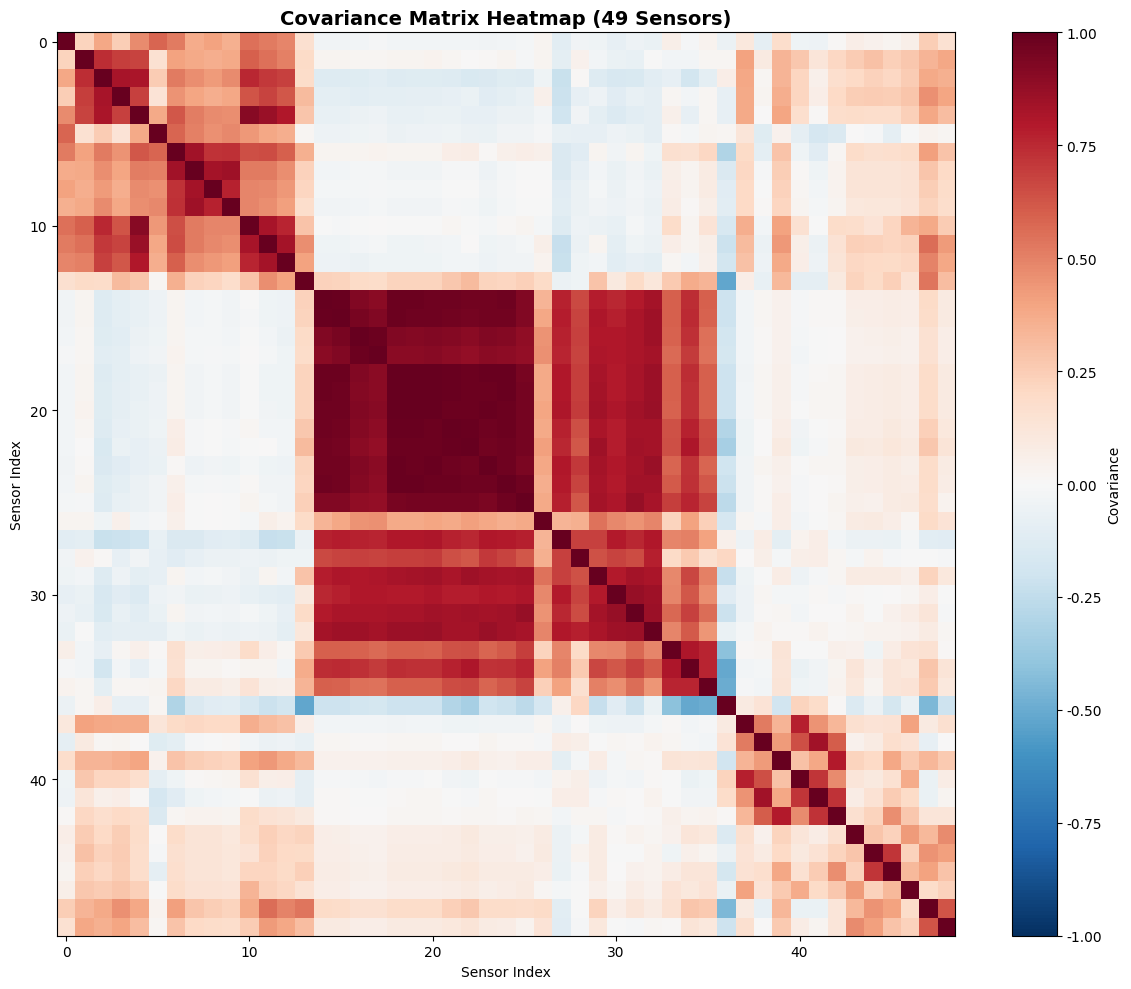


[해석]
  - 빨간색: 양의 상관관계 (함께 증가)
  - 파란색: 음의 상관관계 (반대로 변동)
  - 흰색: 상관관계 없음
  - 일부 센서 그룹 간 강한 상관관계 확인 => 중복 정보 존재


In [32]:
# 공분산 행렬 계산
cov_matrix = np.cov(X_scaled.T)

print(f"[공분산 행렬]")
print(f"  행렬 크기: {cov_matrix.shape}")
print(f"  대각합 (전체 분산): {np.trace(cov_matrix):.2f}")

# 공분산 행렬 히트맵 시각화
plt.figure(figsize=(12, 10))
plt.imshow(cov_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix Heatmap (49 Sensors)', fontsize=14, fontweight='bold')
plt.xlabel('Sensor Index')
plt.ylabel('Sensor Index')
plt.tight_layout()
plt.show()

print("\n[해석]")
print("  - 빨간색: 양의 상관관계 (함께 증가)")
print("  - 파란색: 음의 상관관계 (반대로 변동)")
print("  - 흰색: 상관관계 없음")
print("  - 일부 센서 그룹 간 강한 상관관계 확인 => 중복 정보 존재")

In [33]:
# PCA 수행 (전체 성분)
pca_full = PCA()
pca_full.fit(X_scaled)

# 고유값 (설명 분산)
eigenvalues = pca_full.explained_variance_
explained_ratio = pca_full.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

print("[고유값 분석 결과]")
print(f"{'PC':>4} | {'Eigenvalue':>12} | {'Variance %':>12} | {'Cumulative %':>12}")
print("-" * 50)
for i in range(min(15, len(eigenvalues))):
    print(f"PC{i+1:>2} | {eigenvalues[i]:>12.4f} | {explained_ratio[i]*100:>11.2f}% | {cumulative_ratio[i]*100:>11.2f}%")
print("-" * 50)

# 95% 설명에 필요한 주성분 수
n_components_95 = np.argmax(cumulative_ratio >= 0.95) + 1
print(f"\n전체 분산의 95%를 설명하는 데 필요한 주성분 수: {n_components_95}개")
print(f"  => 49개 변수를 {n_components_95}개로 축소해도 95% 정보 보존")

[고유값 분석 결과]
  PC |   Eigenvalue |   Variance % | Cumulative %
--------------------------------------------------
PC 1 |      17.4613 |       35.63% |       35.63%
PC 2 |       9.2108 |       18.80% |       54.43%
PC 3 |       4.1399 |        8.45% |       62.88%
PC 4 |       2.7371 |        5.59% |       68.46%
PC 5 |       2.0434 |        4.17% |       72.63%
PC 6 |       1.5304 |        3.12% |       75.75%
PC 7 |       1.2669 |        2.59% |       78.34%
PC 8 |       1.0779 |        2.20% |       80.54%
PC 9 |       1.0068 |        2.05% |       82.59%
PC10 |       0.8790 |        1.79% |       84.39%
PC11 |       0.8301 |        1.69% |       86.08%
PC12 |       0.6806 |        1.39% |       87.47%
PC13 |       0.4972 |        1.01% |       88.48%
PC14 |       0.4653 |        0.95% |       89.43%
PC15 |       0.4378 |        0.89% |       90.33%
--------------------------------------------------

전체 분산의 95%를 설명하는 데 필요한 주성분 수: 23개
  => 49개 변수를 23개로 축소해도 95% 정보 보존


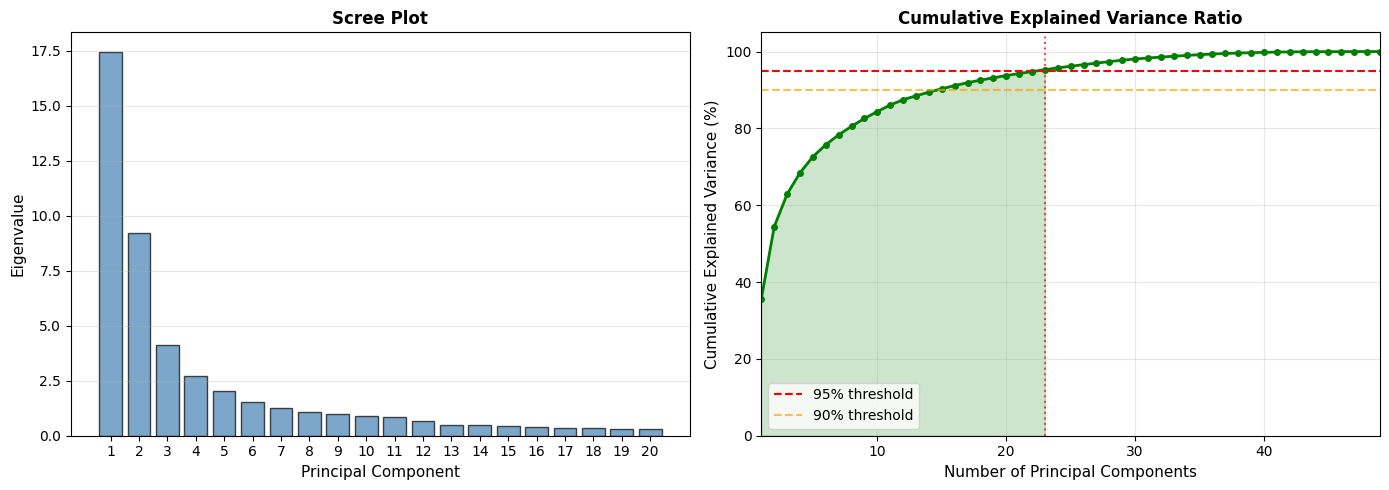


[시각화 해석]
  스크리 플롯: PC1, PC2에서 급격한 감소 후 완만해짐 (엘보우 지점)
  누적 분산: PC10 이전에 대부분의 분산 설명


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 스크리 플롯 (Scree Plot)
ax1 = axes[0]
ax1.bar(range(1, len(eigenvalues[:20])+1), eigenvalues[:20], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Eigenvalue', fontsize=11)
ax1.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 21))
ax1.grid(True, alpha=0.3, axis='y')

# 누적 설명 분산
ax2 = axes[1]
ax2.plot(range(1, len(cumulative_ratio)+1), cumulative_ratio * 100, 
         'go-', linewidth=2, markersize=4)
ax2.axhline(y=95, color='r', linestyle='--', label='95% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.axvline(x=n_components_95, color='r', linestyle=':', alpha=0.7)
ax2.fill_between(range(1, n_components_95+1), 0, 
                  cumulative_ratio[:n_components_95]*100, alpha=0.2, color='green')
ax2.set_xlabel('Number of Principal Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
ax2.set_title('Cumulative Explained Variance Ratio', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, len(cumulative_ratio))
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print("  스크리 플롯: PC1, PC2에서 급격한 감소 후 완만해짐 (엘보우 지점)")
print("  누적 분산: PC10 이전에 대부분의 분산 설명")

In [35]:
# 주성분 로딩 (각 원본 변수가 주성분에 기여하는 정도)
loadings = pca_full.components_

# PC1, PC2 로딩 분석
print("[PC1 로딩 분석 - 상위 10개 센서]")
pc1_loadings = pd.Series(loadings[0], index=good_sensors)
pc1_top = pc1_loadings.abs().nlargest(10)
print(f"{'Sensor':>12} | {'Loading':>10} | {'Direction':>10}")
print("-" * 40)
for sensor in pc1_top.index:
    loading = pc1_loadings[sensor]
    direction = "positive" if loading > 0 else "negative"
    print(f"{sensor:>12} | {loading:>10.4f} | {direction:>10}")

print("\n[해석]")
print("  - 로딩 절댓값이 클수록 해당 센서가 PC1에 큰 영향")
print("  - 양수: PC1 증가와 같은 방향")
print("  - 음수: PC1 증가와 반대 방향")

[PC1 로딩 분석 - 상위 10개 센서]
      Sensor |    Loading |  Direction
----------------------------------------
   sensor_21 |     0.2352 |   positive
   sensor_19 |     0.2347 |   positive
   sensor_23 |     0.2346 |   positive
   sensor_20 |     0.2345 |   positive
   sensor_22 |     0.2344 |   positive
   sensor_25 |     0.2335 |   positive
   sensor_24 |     0.2332 |   positive
   sensor_16 |     0.2322 |   positive
   sensor_26 |     0.2312 |   positive
   sensor_14 |     0.2305 |   positive

[해석]
  - 로딩 절댓값이 클수록 해당 센서가 PC1에 큰 영향
  - 양수: PC1 증가와 같은 방향
  - 음수: PC1 증가와 반대 방향


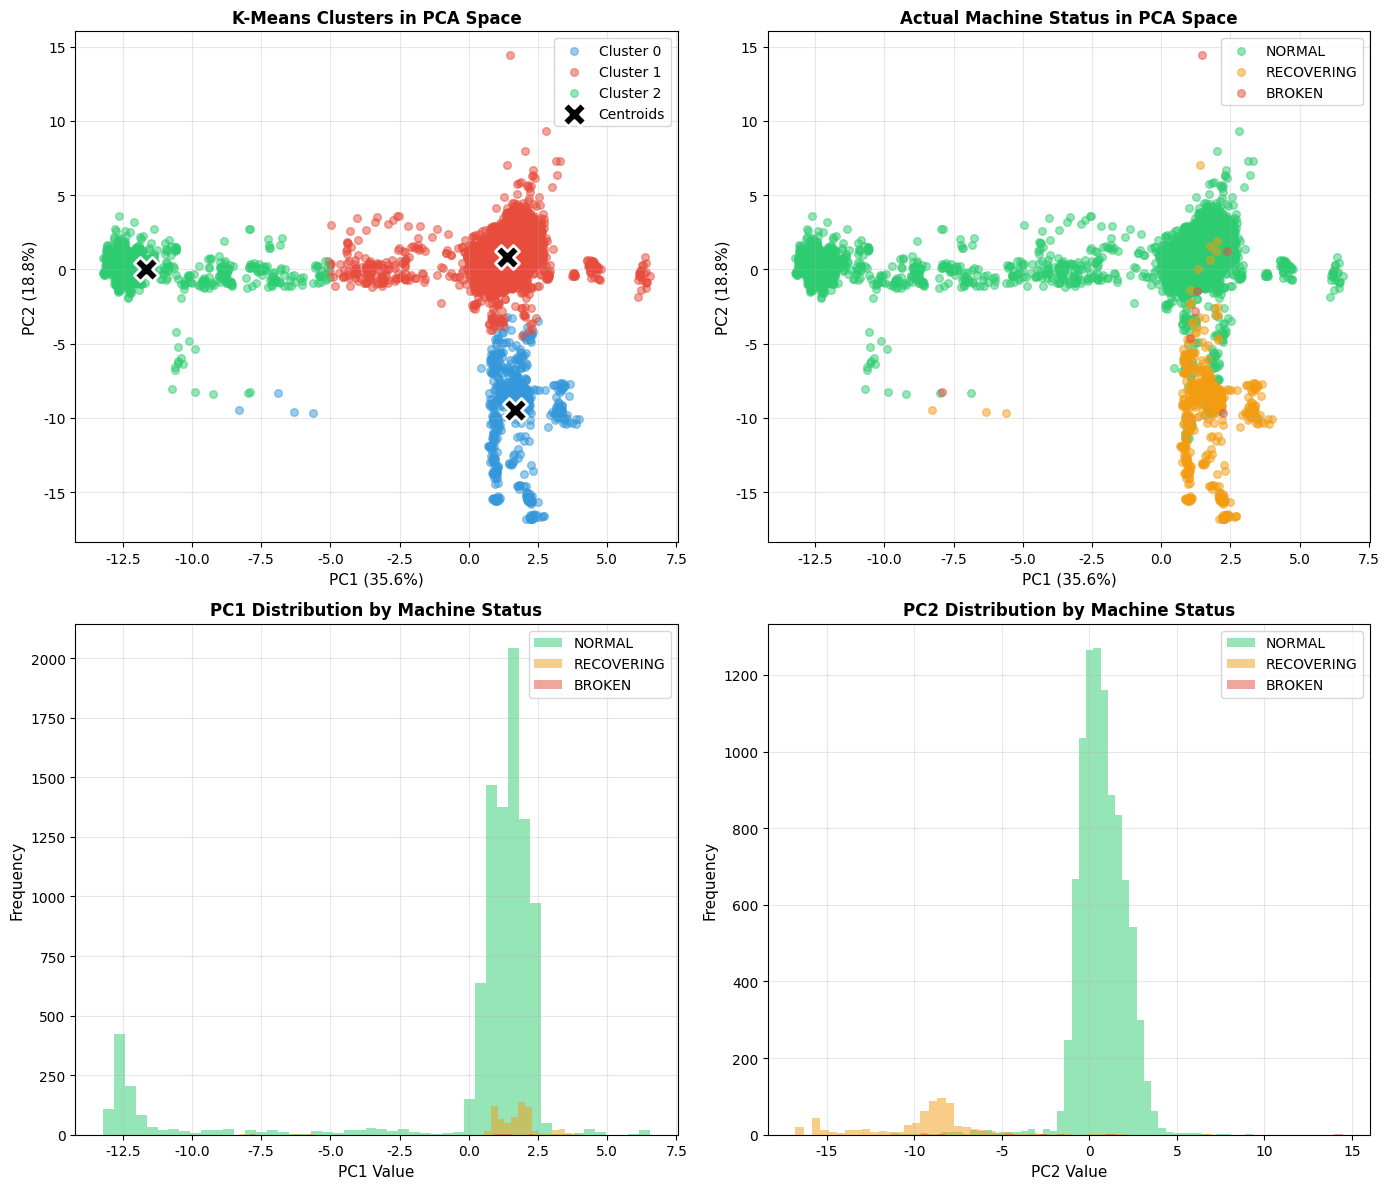


[시각화 해석]
  좌상: PCA 공간에서의 K-Means 군집 분포
  우상: 실제 기계 상태별 분포 (군집과 비교)
  좌하: PC1 값의 상태별 분포 - 상태 구분에 PC1이 유용한지 확인
  우하: PC2 값의 상태별 분포 - 추가적인 구분력 확인


In [36]:
# 2개 주성분으로 변환
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# K-Means 클러스터링 (본 강의 결과 활용)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
centers_pca = pca_2d.transform(kmeans.cluster_centers_)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1) 군집별 분포
ax1 = axes[0, 0]
colors = ['#3498db', '#e74c3c', '#2ecc71']
for i in range(3):
    mask = labels == i
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', 
            marker='X', s=300, edgecolors='white', linewidths=2, 
            label='Centroids', zorder=5)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('K-Means Clusters in PCA Space', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2) 실제 기계 상태
ax2 = axes[0, 1]
status_colors = {'NORMAL': '#2ecc71', 'RECOVERING': '#f39c12', 'BROKEN': '#e74c3c'}
for status in ['NORMAL', 'RECOVERING', 'BROKEN']:
    mask = y_status == status
    if mask.sum() > 0:
        ax2.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                    c=status_colors[status], label=status, alpha=0.5, s=30)
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Actual Machine Status in PCA Space', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3) PC1 분포 (상태별)
ax3 = axes[1, 0]
for status in ['NORMAL', 'RECOVERING', 'BROKEN']:
    mask = y_status == status
    if mask.sum() > 0:
        ax3.hist(X_pca_2d[mask, 0], bins=50, alpha=0.5, 
                 label=status, color=status_colors[status])
ax3.set_xlabel('PC1 Value', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('PC1 Distribution by Machine Status', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4) PC2 분포 (상태별)
ax4 = axes[1, 1]
for status in ['NORMAL', 'RECOVERING', 'BROKEN']:
    mask = y_status == status
    if mask.sum() > 0:
        ax4.hist(X_pca_2d[mask, 1], bins=50, alpha=0.5, 
                 label=status, color=status_colors[status])
ax4.set_xlabel('PC2 Value', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('PC2 Distribution by Machine Status', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print("  좌상: PCA 공간에서의 K-Means 군집 분포")
print("  우상: 실제 기계 상태별 분포 (군집과 비교)")
print("  좌하: PC1 값의 상태별 분포 - 상태 구분에 PC1이 유용한지 확인")
print("  우하: PC2 값의 상태별 분포 - 추가적인 구분력 확인")

In [38]:
# 다양한 차원에서 K-Means 수행
dimensions = [2, 5, 10, 20, 30, 49]  # 49 = 원본 차원
results = []

for n_dim in dimensions:
    if n_dim == 49:
        X_reduced = X_scaled
    else:
        pca_temp = PCA(n_components=n_dim)
        X_reduced = pca_temp.fit_transform(X_scaled)
        evr = sum(pca_temp.explained_variance_ratio_)
    
    # K-Means 수행
    kmeans_temp = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_reduced)
    
    # 실루엣 점수 계산
    from sklearn.metrics import silhouette_score
    sil_score = silhouette_score(X_reduced, labels_temp)
    
    # 설명 분산비 (원본은 100%)
    if n_dim == 49:
        evr = 1.0
    
    results.append({
        'dimensions': n_dim,
        'explained_variance': evr,
        'silhouette_score': sil_score,
        'inertia': kmeans_temp.inertia_
    })

results_df = pd.DataFrame(results)
print("[차원별 군집화 성능 비교]")
print(results_df.to_string(index=False))

[차원별 군집화 성능 비교]
 dimensions  explained_variance  silhouette_score       inertia
          2            0.544274          0.807586  31906.911406
          5            0.726305          0.681868 119670.878420
         10            0.843865          0.633662 176576.422145
         20            0.937487          0.587852 222357.487075
         30            0.980559          0.571304 243451.637284
         49            1.000000          0.563990 252976.469817


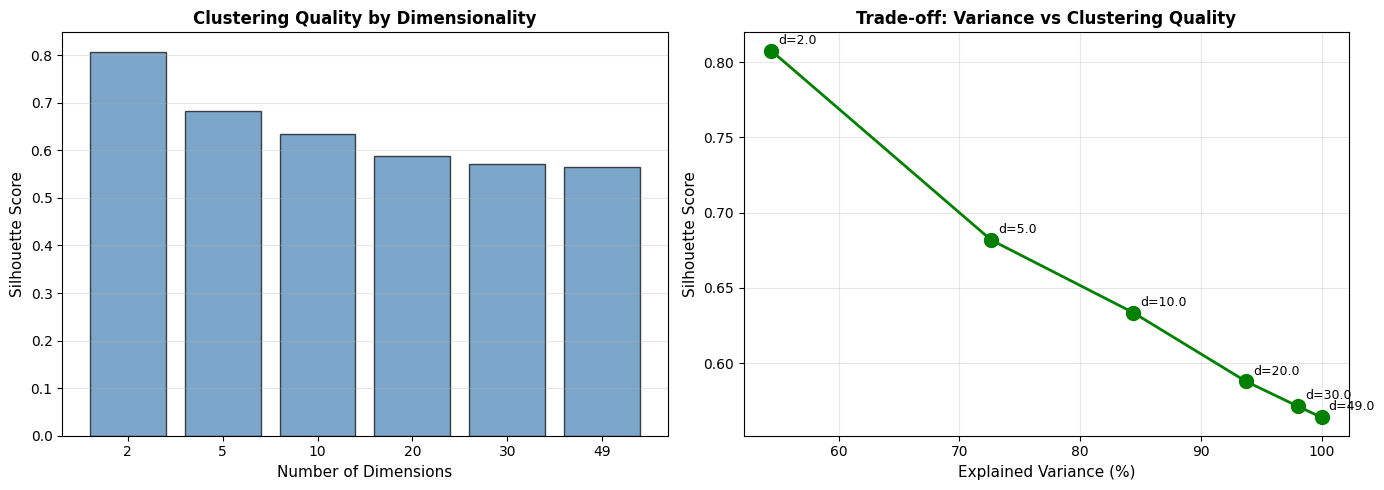


[분석 결과]
  - 적절한 차원 축소가 오히려 군집화 품질을 향상시킬 수 있음
  - 노이즈 제거 효과로 군집 경계가 더 명확해짐
  - 계산 효율성도 크게 향상 (변수 수 감소)


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 실루엣 점수 비교
ax1 = axes[0]
ax1.bar(range(len(dimensions)), results_df['silhouette_score'], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(dimensions)))
ax1.set_xticklabels([str(d) for d in dimensions])
ax1.set_xlabel('Number of Dimensions', fontsize=11)
ax1.set_ylabel('Silhouette Score', fontsize=11)
ax1.set_title('Clustering Quality by Dimensionality', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 설명 분산 vs 실루엣 점수
ax2 = axes[1]
ax2.plot(results_df['explained_variance']*100, results_df['silhouette_score'], 
         'go-', linewidth=2, markersize=10)
for i, row in results_df.iterrows():
    ax2.annotate(f"d={row['dimensions']}", 
                 (row['explained_variance']*100, row['silhouette_score']),
                 textcoords="offset points", xytext=(5,5), fontsize=9)
ax2.set_xlabel('Explained Variance (%)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Trade-off: Variance vs Clustering Quality', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[분석 결과]")
print("  - 적절한 차원 축소가 오히려 군집화 품질을 향상시킬 수 있음")
print("  - 노이즈 제거 효과로 군집 경계가 더 명확해짐")
print("  - 계산 효율성도 크게 향상 (변수 수 감소)")